# Directed SA Variation Across Multiple Empirical Networks

This notebook runs the directed simulated-annealing intervention pipeline over every loadable empirical graph in `NetworkInequality/empirical_networks`.

It keeps the same asymmetric scoring principle as the single-network notebook:

- target statistic: plateau once inside tolerance
- preserved statistics: hard tolerance band plus centered penalty back toward baseline
- feasible-state selection: preservation centering first, then edit distance

For each source network it:

- loads and normalizes the graph as a simple directed graph
- records baseline statistics
- builds a source-specific config using the same rules for every network
- optionally calibrates tolerances from local move noise
- runs the full target sweep
- saves every feasible generated network as a NetworkX pickle with restored node labels and node attributes
- saves sparse adjacency matrices and result metadata tables
- prints the same pre-plot diagnostics used in the single-network workflow


In [7]:
%reload_ext autoreload
%autoreload 2

from dataclasses import replace
from pathlib import Path
import fnmatch
import math
import pickle

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from IPython.display import display

from utils.sa_network_variation_directed import (
    SAConfig,
    GraphState,
    aggregate_correlations,
    calibrate_tolerances_from_local_moves,
    compute_group_correlation_tables,
    compute_overall_correlation_matrix,
    compute_overall_correlation_table,
    compute_residualized_correlation_matrix,
    compute_residualized_correlation_table,
    compute_target_intervention_diagnostics,
    estimate_all_target_grids,
    load_source_graph,
    replay_result_trace,
    resolve_source_paths,
    run_batch_sweep,
    save_graph_state,
    summarize_compression_effectiveness,
    summarize_preservation_drift,
)

pd.set_option("display.max_columns", 180)
pd.set_option("display.width", 180)


In [22]:
import matplotlib.pyplot as plt
from matplotlib import font_manager
from pathlib import Path

plt.style.use("opinionated_rc")
font_dir = Path.home() / "Downloads" / "Source_Sans_3" / "static"

source_sans_3_paths = [
    font_dir / "SourceSans3-Regular.ttf",
    font_dir / "SourceSans3-Bold.ttf",
    font_dir / "SourceSans3-Italic.ttf",
    font_dir / "SourceSans3-BoldItalic.ttf",
]

missing = [path for path in source_sans_3_paths if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Missing Source Sans 3 font files: "
        + ", ".join(str(path) for path in missing)
    )

for font_path in source_sans_3_paths:
    font_manager.fontManager.addfont(str(font_path))

plt.rcParams["font.family"] = ["Source Sans 3"]
plt.rcParams["font.sans-serif"] = [
    "Source Sans 3",
    *plt.rcParams.get("font.sans-serif", []),
]



In [ ]:
6e-4

0.0006

In [ ]:
from pathlib import Path

PROJECT_ROOT_CANDIDATES = [
    Path.cwd(),
    Path.cwd() / "e_network_inequality",
    *Path.cwd().parents,
    *(parent / "e_network_inequality" for parent in Path.cwd().parents),
]
PROJECT_ROOT = next(
    (
        candidate
        for candidate in PROJECT_ROOT_CANDIDATES
        if (candidate / "networks" / "citation_data").exists()
    ),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate networks/citation_data from the current working directory")

EMPIRICAL_DIR = PROJECT_ROOT / "networks" / "citation_data"
OUTPUT_ROOT = PROJECT_ROOT / "sa_variation_outputs_directed_multi_v5"

TABLES_DIR = OUTPUT_ROOT / "tables"  # parquet summaries and metadata
BASELINES_DIR = OUTPUT_ROOT / "baselines"  # normalized empirical baselines

NETWORK_PATTERNS = ("*.pkl",)  # source files to consider
EXCLUDE_NAME_PATTERNS = ("*_dill.pkl",)  # skip files that need extra dill/module state

# Set this to a shorter explicit list while developing, e.g. ["ego_network.pkl", "pud_final.pkl"].
ONLY_NETWORK_NAMES: list[str] | None =  ['ego_network.pkl', 'pud_network.pkl','tobacco_network.pkl']  # None means use every discovered source

N_JOBS = -1  # -1 uses all available cores; 1 is serial
RUN_NETWORKS = True  # False stops before the expensive batch run
# Pilot target-grid estimation runs annealing. Keep this False unless you really
# want to spend that time before the batch; run_batch_sweep computes true grids once.
RUN_EXPENSIVE_GRID_PREVIEW = False  # True previews exact pilot grids but duplicates pilot work
USE_CALIBRATED_TOLERANCES = True  # adapt tolerances from local move noise per source
TOLERANCE_CALIBRATION_SAMPLES_PER_TARGET = 512  # local proposal samples per target stat
TOLERANCE_CALIBRATION_QUANTILE = 0.9  # robust local-move scale estimate
TOLERANCE_CALIBRATION_MULTIPLIER = 3.0  # tolerance = multiplier * local scale, with floors

# Grid policy options:
# - "pilot": estimate reachable target ranges by pilot annealing per network/stat.
# - "baseline_relative_asymmetric": old baseline-scaled half-width rule, but with
#   lower and upper sides clipped independently against [0, 1].
# - "baseline_relative_centered": old behavior, where both sides are clipped by
#   the smaller side of the available [0, 1] headroom.
# Manual SOURCE_CFG_OVERRIDES below are applied last and can set explicit bounds.
GRID_MODE_POLICY = "baseline_relative_asymmetric"
AUTO_BASELINE_RELATIVE_WIDTH_FRACTIONS = {
    "density": 0.70,
    "degree_gini": 0.70,
    "clustering": 0.75,
}
AUTO_BASELINE_RELATIVE_MIN_WIDTHS = {  # prevents tiny baseline ranges
    "density": 1e-4,
    "degree_gini": 0.01,
    "clustering": 0.01,
}
AUTO_BASELINE_RELATIVE_MAX_WIDTHS = {  # prevents unrealistic ranges
    "density": 0.04,
    "degree_gini": 0.5,
    "clustering": 0.5,
}
TARGET_TOLERANCE_HALF_WIDTH_FRACTIONS = {
    "density": 0.05,
    "degree_gini": 0.05,
    "clustering": 0.05,
}
TARGET_TOLERANCE_MIN_VALUES = {
    "density": 0.0,
    "degree_gini": 5e-4,
    "clustering": 5e-4,
}
TARGET_TOLERANCE_GRID_STEP_FRACTION = 0.40  # keep target bands below half a grid step
PRESERVE_TOLERANCE_GRID_STEP_FRACTION = 1.00  # keep preserved stats within about one grid step
DENSITY_TARGET_TOLERANCE_MIN_EDGE_STEPS = 0.51  # enough to catch the nearest integer edge count

# Optional explicit per-network config overrides. Keys are source_id/path.stem.
# Examples:
# SOURCE_CFG_OVERRIDES = {
#     "ego_network": {
#         "target_grid_mode": "centered",
#         "centered_grid_half_widths": {"density": 0.003, "degree_gini": 0.08, "clustering": 0.10},
#     },
#     "perceptron_final": {
#         "target_grid_mode": "explicit",
#         "explicit_grid_bounds": {"density": (0.001, 0.006), "degree_gini": (0.70, 0.95), "clustering": (0.10, 0.40)},
#         "n_target_grid": 21,
#     },
# }
SOURCE_CFG_OVERRIDES: dict[str, dict[str, object]] = {}  # manual source-specific overrides

# All feasible final networks are saved. This cap is deliberately much larger
# than n_target_grid * n_seeds for normal runs.
SAVE_ALL_GRAPH_CAP = 1_000_000  # effectively save every feasible graph

base_cfg = SAConfig(
    output_dir=OUTPUT_ROOT,  # root for matrices, saved graphs, and run outputs
    degree_gini_mode="out",  # degree gini uses out-degree in directed graphs
    connectivity_mode="weak",  # preserve weak connectivity, ignoring edge direction
    keep_largest_component=True,  # normalize disconnected inputs to largest component
    target_grid_mode="pilot",  # may be replaced by GRID_MODE_POLICY per source
    target_tolerances={  # acceptable target miss in raw statistic units
        "density": 6e-4,
        "degree_gini": 3e-3,
        "clustering": 3e-3,
    },
    preserve_tolerances={  # hard off-target preservation bands in raw units
        "density": 6e-4,
        "degree_gini": 3e-3,
        "clustering": 3e-3,
    },
    
    
    pilot_runs_per_direction=6,  # pilot probes per stat direction when using pilot grids
    pilot_steps=1500,  # annealing steps per pilot probe
    attain_steps=12000,  # steps to reach the target/preserve feasible band
    compress_steps=6000,  # steps to reduce edit distance after attainment
    temperature_block_size=200,  # annealing temperature update interval
    cooling_alpha=0.97,  # multiplicative cooling rate per block
    stall_blocks=12,  # stop after this many blocks without improvement
    targeted_move_prob=0.7,  # probability of using target-aware move sampler
    best_of_k=32,  # candidate moves scored per step; higher is cleaner but slower
    candidate_trials=96,  # internal retries for finding legal candidate moves
    node_selection_batch=16,  # candidate node pool for endpoint choices
    density_repair_swap_prob=0.25,  # chance of repair-style density move in density target
    
    n_target_grid=100,  # number of target values per stat/network
    n_seeds=1,  # independent SA runs per target value
    
    random_seed=7,  # base seed for reproducible batches
    n_jobs=N_JOBS,  # multiprocessing workers
    save_selected_graphs=True,  # save generated NetworkX graphs
    max_saved_graphs_per_group=SAVE_ALL_GRAPH_CAP,  # cap saved graphs per source/stat
    save_run_matrices=True,  # save final adjacency matrices for embeddings/UMAP
    state_matrix_format="csr",  # sparse matrix format for saved adjacencies
    stop_attain_on_first_feasible=True,  # switch to compression as soon as feasible
    compress_no_improvement_patience=400,  # stop compression after no better feasible state
    in_band_loss_mode="target_zero_preserve_exact",  # target plateaus; preserved stats stay centered
    compress_preserve_weight=8.0,  # preservation-centering strength during compression
    feasible_preserve_weight=250.0,  # preservation weight in feasible-state selection
    feasible_selection_mode="preserve_first",  # final feasible choice prioritizes centered preservation
    show_progress=True,  # tqdm progress bars
)

smoke_cfg = replace(
    base_cfg,
    pilot_runs_per_direction=3,  # cheap pilot probes for mechanical tests
    pilot_steps=40,  # tiny pilot budget
    attain_steps=120,  # tiny attainment budget
    compress_steps=80,  # tiny compression budget
    best_of_k=4,  # faster candidate scoring for smoke tests
    candidate_trials=24,  # fewer legality retries for smoke tests
    node_selection_batch=8,  # smaller endpoint candidate pool
    n_target_grid=5,  # fewer target values
    n_seeds=1,  # one seed per target
    save_selected_graphs=True,  # still verify graph saving
    save_run_matrices=False,  # skip matrix output in smoke mode
    show_progress=True,  # keep progress visible
)

# Switch to smoke_cfg for a quick mechanical check.
BASE_ACTIVE_CFG = base_cfg #smoke_cfg #base_cfg  # use smoke_cfg here for a cheap test run
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)  # create output root
TABLES_DIR.mkdir(parents=True, exist_ok=True)  # create table output folder
BASELINES_DIR.mkdir(parents=True, exist_ok=True)  # create normalized baseline folder
BASE_ACTIVE_CFG


SAConfig(target_stats=('density', 'degree_gini', 'clustering'), degree_gini_mode='out', connectivity_mode='weak', keep_largest_component=True, drop_isolates=False, target_grid_mode='pilot', centered_grid_half_widths={'density': 0.002, 'degree_gini': 0.01, 'clustering': 0.02}, explicit_grid_bounds={'density': (0.001, 0.1), 'degree_gini': (0.4, 0.99), 'clustering': (0.05, 0.95)}, target_tolerances={'density': 0.0006, 'degree_gini': 0.003, 'clustering': 0.003}, preserve_tolerances={'density': 0.0006, 'degree_gini': 0.003, 'clustering': 0.003}, pilot_runs_per_direction=6, pilot_steps=1500, attain_steps=12000, compress_steps=6000, temperature_block_size=200, cooling_alpha=0.97, stall_blocks=12, pilot_temperature_samples=64, initial_acceptance_rate=0.7, targeted_move_prob=0.7, best_of_k=32, candidate_trials=96, node_selection_batch=16, density_repair_swap_prob=0.25, n_target_grid=100, n_seeds=1, grid_quantiles=(0.05, 0.95), random_seed=7, attain_target_weight=5.0, attain_preserve_weight=2.5,

In [ ]:
def discover_source_paths() -> list[Path]:
    paths: list[Path] = []
    for pattern in NETWORK_PATTERNS:
        paths.extend(EMPIRICAL_DIR.glob(pattern))
    paths = sorted(set(paths))
    if ONLY_NETWORK_NAMES is not None:
        allowed = set(ONLY_NETWORK_NAMES)
        paths = [path for path in paths if path.name in allowed]
    paths = [
        path for path in paths
        if not any(fnmatch.fnmatch(path.name, pattern) for pattern in EXCLUDE_NAME_PATTERNS)
    ]
    return paths


def source_id_for_path(path: Path) -> str:
    return path.stem


source_paths = discover_source_paths()
print(f"candidate source graphs: {len(source_paths)}")
for path in source_paths:
    print("-", path)


candidate source graphs: 3
- /Users/Noich001/Desktop/network_inequality_current/e_network_inequality/networks/citation_data/ego_network.pkl
- /Users/Noich001/Desktop/network_inequality_current/e_network_inequality/networks/citation_data/pud_network.pkl
- /Users/Noich001/Desktop/network_inequality_current/e_network_inequality/networks/citation_data/tobacco_network.pkl


In [ ]:
def initial_state_for_source(path: Path, cfg: SAConfig) -> tuple[nx.DiGraph, GraphState, dict[str, float]]:
    graph = load_source_graph(path, cfg)
    state = GraphState.from_networkx(graph, degree_gini_mode=cfg.degree_gini_mode)
    return graph, state, state.stats()


def _baseline_relative_width_settings(
    stat_name: str,
    *,
    density_step: float,
) -> tuple[float, float, float]:
    fraction = float(AUTO_BASELINE_RELATIVE_WIDTH_FRACTIONS[stat_name])
    min_width = float(AUTO_BASELINE_RELATIVE_MIN_WIDTHS[stat_name])
    max_width = float(AUTO_BASELINE_RELATIVE_MAX_WIDTHS[stat_name])
    if stat_name == "density":
        min_width = max(min_width, 5.0 * density_step)
    return fraction, min_width, max_width


def autoscaled_centered_half_widths(
    baseline_stats: dict[str, float],
    *,
    density_step: float,
) -> dict[str, float]:
    """Return old-style symmetric centered-grid half widths.

    This remains available for exact backward comparison, but it should not be
    the default for highly skewed statistics such as ego-network degree Gini:
    symmetric half-widths are clipped by the smaller side of [0, 1].
    """

    half_widths: dict[str, float] = {}
    for stat_name, baseline_value_raw in baseline_stats.items():
        baseline_value = float(baseline_value_raw)
        fraction, min_width, max_width = _baseline_relative_width_settings(
            stat_name,
            density_step=density_step,
        )
        available = max(0.0, min(baseline_value, 1.0 - baseline_value))
        proposed = max(min_width, fraction * max(abs(baseline_value), min_width))
        half_widths[stat_name] = float(min(max_width, proposed, available))
    return half_widths


def autoscaled_baseline_relative_bounds(
    baseline_stats: dict[str, float],
    *,
    density_step: float,
) -> dict[str, tuple[float, float]]:
    """Return explicit bounds from the old half-width rule.

    The proposed half-width is computed exactly as in the old centered policy.
    The only difference is that lower and upper sides are clipped independently
    against [0, 1], so an upper boundary does not also shrink the lower side.
    """

    bounds: dict[str, tuple[float, float]] = {}
    for stat_name, baseline_value_raw in baseline_stats.items():
        baseline_value = float(baseline_value_raw)
        fraction, min_width, max_width = _baseline_relative_width_settings(
            stat_name,
            density_step=density_step,
        )
        proposed = max(min_width, fraction * max(abs(baseline_value), min_width))
        lower_width = min(max_width, proposed, max(0.0, baseline_value))
        upper_width = min(max_width, proposed, max(0.0, 1.0 - baseline_value))
        lower = max(0.0, baseline_value - lower_width)
        upper = min(1.0, baseline_value + upper_width)
        bounds[stat_name] = (float(lower), float(upper))
    return bounds


def _grid_step_from_bounds(bounds: tuple[float, float], n_target_grid: int) -> float:
    if n_target_grid <= 1:
        return 0.0
    lower, upper = bounds
    return max(0.0, float(upper) - float(lower)) / float(n_target_grid - 1)


def _bounds_for_configured_grid(
    cfg: SAConfig,
    stat_name: str,
    *,
    baseline_value: float,
) -> tuple[float, float] | None:
    if cfg.target_grid_mode == "explicit":
        lower, upper = cfg.explicit_grid_bounds[stat_name]
        return (max(0.0, float(lower)), min(1.0, float(upper)))
    if cfg.target_grid_mode == "centered":
        half_width = float(cfg.centered_grid_half_widths[stat_name])
        return (
            max(0.0, float(baseline_value) - half_width),
            min(1.0, float(baseline_value) + half_width),
        )
    return None


def autoscaled_target_tolerances(
    cfg: SAConfig,
    baseline_stats: dict[str, float],
    *,
    density_step: float,
    centered_half_widths: dict[str, float] | None = None,
    target_bounds: dict[str, tuple[float, float]] | None = None,
) -> dict[str, float]:
    target_tolerances = dict(cfg.target_tolerances)

    if centered_half_widths is None:
        centered_half_widths = autoscaled_centered_half_widths(
            baseline_stats,
            density_step=density_step,
        )

    for stat_name, baseline_value_raw in baseline_stats.items():
        baseline_value = float(baseline_value_raw)
        if target_bounds is not None and stat_name in target_bounds:
            lower, upper = target_bounds[stat_name]
            width_for_scaling = max(abs(baseline_value - lower), abs(upper - baseline_value))
            grid_step = _grid_step_from_bounds((lower, upper), cfg.n_target_grid)
        else:
            half_width = float(centered_half_widths[stat_name])
            width_for_scaling = half_width
            grid_step = _grid_step_from_bounds(
                (baseline_value - half_width, baseline_value + half_width),
                cfg.n_target_grid,
            )

        grid_ceiling = TARGET_TOLERANCE_GRID_STEP_FRACTION * grid_step
        scaled = TARGET_TOLERANCE_HALF_WIDTH_FRACTIONS[stat_name] * width_for_scaling
        scaled = min(float(cfg.target_tolerances[stat_name]), scaled)
        floor = float(TARGET_TOLERANCE_MIN_VALUES[stat_name])

        if stat_name == "density":
            floor = max(floor, DENSITY_TARGET_TOLERANCE_MIN_EDGE_STEPS * density_step)

        if grid_ceiling > 0.0:
            scaled = min(scaled, grid_ceiling)
            if floor < grid_ceiling:
                scaled = max(floor, scaled)
        else:
            scaled = max(floor, scaled)

        target_tolerances[stat_name] = float(scaled)

    return target_tolerances


def apply_source_cfg_overrides(cfg: SAConfig, source_id: str) -> SAConfig:
    overrides = SOURCE_CFG_OVERRIDES.get(source_id, {})
    if not overrides:
        return cfg
    return replace(cfg, **overrides)


def adapt_cfg_for_source(
    base: SAConfig,
    path: Path,
    state: GraphState,
    baseline_stats: dict[str, float],
) -> SAConfig:
    """Apply source-specific rules that are structural, not condition-specific."""

    source_id = source_id_for_path(path)
    density_step = 1.0 / max(1, state.n * (state.n - 1))
    preserve_tolerances = dict(base.preserve_tolerances)
    preserve_tolerances["density"] = max(preserve_tolerances["density"], 3.0 * density_step)

    best_of_k = base.best_of_k
    candidate_trials = base.candidate_trials
    if state.n >= 2_000:
        # Same scoring objective, narrower candidate search for large graphs.
        best_of_k = min(best_of_k, 16)
        candidate_trials = min(candidate_trials, 64)

    grid_kwargs: dict[str, object] = {}
    centered_half_widths = autoscaled_centered_half_widths(
        baseline_stats,
        density_step=density_step,
    )
    target_bounds: dict[str, tuple[float, float]] | None = None

    if GRID_MODE_POLICY == "baseline_relative_asymmetric":
        target_bounds = autoscaled_baseline_relative_bounds(
            baseline_stats,
            density_step=density_step,
        )
        grid_kwargs = {
            "target_grid_mode": "explicit",
            "explicit_grid_bounds": target_bounds,
        }
    elif GRID_MODE_POLICY == "baseline_relative_centered":
        grid_kwargs = {
            "target_grid_mode": "centered",
            "centered_grid_half_widths": centered_half_widths,
        }
    elif GRID_MODE_POLICY == "pilot":
        grid_kwargs = {"target_grid_mode": "pilot"}
    else:
        raise ValueError(f"Unknown GRID_MODE_POLICY: {GRID_MODE_POLICY!r}")

    target_tolerances = autoscaled_target_tolerances(
        base,
        baseline_stats,
        density_step=density_step,
        centered_half_widths=centered_half_widths,
        target_bounds=target_bounds,
    )

    cfg = replace(
        base,
        target_tolerances=target_tolerances,
        preserve_tolerances=preserve_tolerances,
        best_of_k=best_of_k,
        candidate_trials=candidate_trials,
        progress_desc=f"SA {source_id}",
        **grid_kwargs,
    )
    return apply_source_cfg_overrides(cfg, source_id)


def cap_preserve_tolerances_from_grid(
    cfg: SAConfig,
    baseline_stats: dict[str, float],
    *,
    density_step: float,
) -> SAConfig:
    preserve_tolerances = dict(cfg.preserve_tolerances)
    for stat_name in cfg.target_stats:
        bounds = _bounds_for_configured_grid(
            cfg,
            stat_name,
            baseline_value=float(baseline_stats[stat_name]),
        )
        if bounds is None:
            continue
        grid_step = _grid_step_from_bounds(bounds, cfg.n_target_grid)
        if grid_step <= 0.0:
            continue
        ceiling = PRESERVE_TOLERANCE_GRID_STEP_FRACTION * grid_step
        floor = float(TARGET_TOLERANCE_MIN_VALUES[stat_name])
        if stat_name == "density":
            floor = max(floor, DENSITY_TARGET_TOLERANCE_MIN_EDGE_STEPS * density_step)
        preserve_tolerances[stat_name] = min(
            float(preserve_tolerances[stat_name]),
            max(floor, ceiling),
        )
    return replace(cfg, preserve_tolerances=preserve_tolerances)


def calibrated_cfg_for_source(
    cfg: SAConfig,
    state: GraphState,
    baseline_stats: dict[str, float],
) -> tuple[SAConfig, pd.DataFrame, pd.DataFrame]:
    density_step = 1.0 / max(1, state.n * (state.n - 1))
    if not USE_CALIBRATED_TOLERANCES:
        return cap_preserve_tolerances_from_grid(
            cfg,
            baseline_stats,
            density_step=density_step,
        ), pd.DataFrame(), pd.DataFrame()
    calibrated_cfg, diagnostics_df, samples_df = calibrate_tolerances_from_local_moves(
        state,
        baseline_stats,
        cfg,
        n_samples_per_target=TOLERANCE_CALIBRATION_SAMPLES_PER_TARGET,
        quantile=TOLERANCE_CALIBRATION_QUANTILE,
        multiplier=TOLERANCE_CALIBRATION_MULTIPLIER,
        seed=cfg.random_seed,
        apply_to=("preserve",),
    )
    calibrated_cfg = cap_preserve_tolerances_from_grid(
        calibrated_cfg,
        baseline_stats,
        density_step=density_step,
    )
    return calibrated_cfg, diagnostics_df, samples_df


prepared_sources: dict[str, dict[str, object]] = {}
baseline_rows: list[dict[str, object]] = []
cfg_rows: list[dict[str, object]] = []
tolerance_diag_frames: list[pd.DataFrame] = []
skipped_rows: list[dict[str, object]] = []

for path in source_paths:
    source_id = source_id_for_path(path)
    try:
        graph, state, baseline_stats = initial_state_for_source(path, BASE_ACTIVE_CFG)
        cfg = adapt_cfg_for_source(BASE_ACTIVE_CFG, path, state, baseline_stats)
        cfg, tolerance_diag, tolerance_samples = calibrated_cfg_for_source(cfg, state, baseline_stats)
    except Exception as exc:
        skipped_rows.append({"source_id": source_id, "source_path": str(path), "error": repr(exc)})
        continue

    prepared_sources[source_id] = {
        "path": path,
        "graph": graph,
        "state": state,
        "baseline_stats": baseline_stats,
        "cfg": cfg,
        "tolerance_samples": tolerance_samples,
    }
    save_graph_state(state, BASELINES_DIR / f"{source_id}_normalized_baseline.pkl")

    baseline_rows.append(
        {
            "source_id": source_id,
            "source_path": str(path),
            "n": state.n,
            "m": state.m,
            **{f"baseline_{name}": value for name, value in baseline_stats.items()},
        }
    )
    cfg_rows.append(
        {
            "source_id": source_id,
            "target_grid_mode": cfg.target_grid_mode,
            "grid_mode_policy": GRID_MODE_POLICY,
            "has_manual_override": source_id in SOURCE_CFG_OVERRIDES,
            "n_target_grid": cfg.n_target_grid,
            "n_seeds": cfg.n_seeds,
            "best_of_k": cfg.best_of_k,
            "candidate_trials": cfg.candidate_trials,
            "n_jobs": cfg.n_jobs,
            "in_band_loss_mode": cfg.in_band_loss_mode,
            "feasible_selection_mode": cfg.feasible_selection_mode,
            "compress_preserve_weight": cfg.compress_preserve_weight,
            "feasible_preserve_weight": cfg.feasible_preserve_weight,
            **{f"target_tol_{k}": v for k, v in cfg.target_tolerances.items()},
            **{f"preserve_tol_{k}": v for k, v in cfg.preserve_tolerances.items()},
            **{f"centered_half_width_{k}": v for k, v in cfg.centered_grid_half_widths.items()},
            **{f"explicit_lower_{k}": v[0] for k, v in cfg.explicit_grid_bounds.items()},
            **{f"explicit_upper_{k}": v[1] for k, v in cfg.explicit_grid_bounds.items()},
        }
    )
    if not tolerance_diag.empty:
        tolerance_diag_frames.append(tolerance_diag.assign(source_id=source_id, source_path=str(path)))

baseline_df = pd.DataFrame(baseline_rows)
cfg_summary_df = pd.DataFrame(cfg_rows)
tolerance_diagnostics_df = (
    pd.concat(tolerance_diag_frames, ignore_index=True) if tolerance_diag_frames else pd.DataFrame()
)
skipped_sources_df = pd.DataFrame(skipped_rows)

display(baseline_df)
display(cfg_summary_df)
if not tolerance_diagnostics_df.empty:
    display(tolerance_diagnostics_df)
if not skipped_sources_df.empty:
    print("Skipped/unloadable sources:")
    display(skipped_sources_df)

baseline_df.to_parquet(TABLES_DIR / "baseline_stats.parquet", index=False)
cfg_summary_df.to_parquet(TABLES_DIR / "config_summary.parquet", index=False)
if not tolerance_diagnostics_df.empty:
    tolerance_diagnostics_df.to_parquet(TABLES_DIR / "tolerance_diagnostics.parquet", index=False)
if not skipped_sources_df.empty:
    skipped_sources_df.to_parquet(TABLES_DIR / "skipped_sources.parquet", index=False)


,source_id,source_path,n,m,baseline_density,baseline_degree_gini,baseline_clustering
0,ego_network,/Users/Noich001/Desktop/network_inequality_cur...,503,2933,0.011616,0.920430,0.421697
1,pud_network,/Users/Noich001/Desktop/network_inequality_cur...,90,160,0.019975,0.724583,0.370253
2,tobacco_network,/Users/Noich001/Desktop/network_inequality_cur...,289,1229,0.014766,0.761313,0.299225


,source_id,target_grid_mode,grid_mode_policy,has_manual_override,n_target_grid,n_seeds,best_of_k,candidate_trials,n_jobs,in_band_loss_mode,feasible_selection_mode,compress_preserve_weight,feasible_preserve_weight,target_tol_density,target_tol_degree_gini,target_tol_clustering,preserve_tol_density,preserve_tol_degree_gini,preserve_tol_clustering,centered_half_width_density,centered_half_width_degree_gini,centered_half_width_clustering,explicit_lower_density,explicit_lower_degree_gini,explicit_lower_clustering,explicit_upper_density,explicit_upper_degree_gini,explicit_upper_clustering
0,ego_network,explicit,baseline_relative_asymmetric,False,100,1,32,96,-1,target_zero_preserve_exact,preserve_first,8.0,250.0,0.000066,0.002342,0.002556,0.000164,0.003000,0.003332,0.002,0.01,0.02,0.003485,0.420430,0.105424,0.019746,1.0,0.737970
1,pud_network,explicit,baseline_relative_asymmetric,False,100,1,32,96,-1,target_zero_preserve_exact,preserve_first,8.0,250.0,0.000113,0.003000,0.002244,0.000282,0.007832,0.005610,0.002,0.01,0.02,0.005993,0.224583,0.092563,0.033958,1.0,0.647943
2,tobacco_network,explicit,baseline_relative_asymmetric,False,100,1,32,96,-1,target_zero_preserve_exact,preserve_first,8.0,250.0,0.000084,0.002985,0.001813,0.000209,0.003000,0.004534,0.002,0.01,0.02,0.004430,0.261313,0.074806,0.025102,1.0,0.523643


,stat_name,n_samples,n_positive,median_abs_delta_positive,q0.9_abs_delta_positive,multiplier,floor_tolerance,recommended_tolerance,current_target_tolerance,current_preserve_tolerance,source_id,source_path
0,density,1536,512,0.000004,0.000004,3.0,0.0006,0.000600,0.000066,0.0006,ego_network,/Users/Noich001/Desktop/network_inequality_cur...
1,degree_gini,1536,1023,0.000185,0.000206,3.0,0.0030,0.003000,0.002342,0.0030,ego_network,/Users/Noich001/Desktop/network_inequality_cur...
2,clustering,1536,1513,0.000124,0.001111,3.0,0.0030,0.003332,0.002556,0.0030,ego_network,/Users/Noich001/Desktop/network_inequality_cur...
3,density,1536,512,0.000125,0.000125,3.0,0.0006,0.000600,0.000113,0.0006,pud_network,/Users/Noich001/Desktop/network_inequality_cur...
4,degree_gini,1536,1009,0.004984,0.006528,3.0,0.0030,0.019583,0.003000,0.0030,pud_network,/Users/Noich001/Desktop/network_inequality_cur...
5,clustering,1536,1395,0.005473,0.022152,3.0,0.0030,0.066456,0.002244,0.0030,pud_network,/Users/Noich001/Desktop/network_inequality_cur...
6,density,1536,512,0.000012,0.000012,3.0,0.0006,0.000600,0.000084,0.0006,tobacco_network,/Users/Noich001/Desktop/network_inequality_cur...
7,degree_gini,1536,1010,0.000684,0.000991,3.0,0.0030,0.003000,0.002985,0.0030,tobacco_network,/Users/Noich001/Desktop/network_inequality_cur...
8,clustering,1536,1489,0.000361,0.001844,3.0,0.0030,0.005532,0.001813,0.0030,tobacco_network,/Users/Noich001/Desktop/network_inequality_cur...


In [ ]:
# Cheap target-grid plan preview.
# With target_grid_mode="pilot", the true grid is estimated by annealing.
# That is intentionally deferred to run_batch_sweep so we do not run the pilot twice.

def _cheap_target_grid_plan(source_id: str, cfg: SAConfig, baseline_stats: dict[str, float]) -> pd.DataFrame:
    rows = []
    for target_name in cfg.target_stats:
        baseline_value = float(baseline_stats[target_name])
        row = {
            "source_id": source_id,
            "target_stat": target_name,
            "grid_mode": cfg.target_grid_mode,
            "baseline_value": baseline_value,
            "n_target_grid": cfg.n_target_grid,
            "pilot_runs_if_executed": 2 * cfg.pilot_runs_per_direction if cfg.target_grid_mode == "pilot" else 0,
            "pilot_steps_per_run": cfg.pilot_steps if cfg.target_grid_mode == "pilot" else 0,
            "preview_is_exact": cfg.target_grid_mode != "pilot",
        }
        if cfg.target_grid_mode == "explicit":
            lower_raw, upper_raw = cfg.explicit_grid_bounds[target_name]
            lower = max(0.0, min(float(lower_raw), float(upper_raw)))
            upper = min(1.0, max(float(lower_raw), float(upper_raw)))
            row.update({"preview_lower": lower, "preview_upper": upper})
        elif cfg.target_grid_mode == "centered":
            half_width = float(cfg.centered_grid_half_widths[target_name])
            row.update(
                {
                    "preview_lower": max(0.0, baseline_value - half_width),
                    "preview_upper": min(1.0, baseline_value + half_width),
                }
            )
        else:
            row.update(
                {
                    "preview_lower": np.nan,
                    "preview_upper": np.nan,
                    "note": "true pilot bounds are computed once inside run_batch_sweep",
                }
            )
        rows.append(row)
    return pd.DataFrame(rows)


grid_preview_frames: list[pd.DataFrame] = []
for source_id, info in prepared_sources.items():
    state = info["state"]
    baseline_stats = info["baseline_stats"]
    cfg = info["cfg"]
    if RUN_EXPENSIVE_GRID_PREVIEW:
        grid_preview = estimate_all_target_grids(state, baseline_stats, cfg).assign(
            source_id=source_id,
            preview_is_exact=True,
        )
    else:
        grid_preview = _cheap_target_grid_plan(source_id, cfg, baseline_stats)
    grid_preview_frames.append(grid_preview)

all_target_grids_preview_df = (
    pd.concat(grid_preview_frames, ignore_index=True) if grid_preview_frames else pd.DataFrame()
)
display(all_target_grids_preview_df)


,source_id,target_stat,grid_mode,baseline_value,n_target_grid,pilot_runs_if_executed,pilot_steps_per_run,preview_is_exact,preview_lower,preview_upper
0,ego_network,density,explicit,0.011616,100,0,0,True,0.003485,0.019746
1,ego_network,degree_gini,explicit,0.920430,100,0,0,True,0.420430,1.000000
2,ego_network,clustering,explicit,0.421697,100,0,0,True,0.105424,0.737970
3,pud_network,density,explicit,0.019975,100,0,0,True,0.005993,0.033958
4,pud_network,degree_gini,explicit,0.724583,100,0,0,True,0.224583,1.000000
5,pud_network,clustering,explicit,0.370253,100,0,0,True,0.092563,0.647943
6,tobacco_network,density,explicit,0.014766,100,0,0,True,0.004430,0.025102
7,tobacco_network,degree_gini,explicit,0.761313,100,0,0,True,0.261313,1.000000
8,tobacco_network,clustering,explicit,0.299225,100,0,0,True,0.074806,0.523643


In [ ]:
all_results: list[pd.DataFrame] = []
all_grids: list[pd.DataFrame] = []

if RUN_NETWORKS:
    for source_id, info in prepared_sources.items():
        path = info["path"]
        cfg = info["cfg"]
        print(f"\n=== Running {source_id} ===")
        print(path)
        results_df, grid_df = run_batch_sweep([path], cfg)
        results_df = results_df.assign(source_id=source_id)
        grid_df = grid_df.assign(source_id=source_id)

        results_path = TABLES_DIR / f"{source_id}_results.parquet"
        grid_path = TABLES_DIR / f"{source_id}_target_grids.parquet"
        results_df.to_parquet(results_path, index=False)
        grid_df.to_parquet(grid_path, index=False)
        print(f"saved results: {results_path}")
        print(f"saved target grids: {grid_path}")
        print(f"saved feasible graphs under: {cfg.output_dir / 'saved_graphs' / source_id}")

        all_results.append(results_df)
        all_grids.append(grid_df)
else:
    print("RUN_NETWORKS is False; skipping batch execution.")

combined_results_df = pd.concat(all_results, ignore_index=True) if all_results else pd.DataFrame()
combined_target_grids_df = pd.concat(all_grids, ignore_index=True) if all_grids else pd.DataFrame()

if not combined_results_df.empty:
    combined_results_path = TABLES_DIR / "all_networks_results.parquet"
    combined_grids_path = TABLES_DIR / "all_networks_target_grids.parquet"
    combined_results_df.to_parquet(combined_results_path, index=False)
    combined_target_grids_df.to_parquet(combined_grids_path, index=False)
    print(f"combined results: {combined_results_path}")
    print(f"combined target grids: {combined_grids_path}")



=== Running ego_network ===
/Users/Noich001/Desktop/network_inequality_current/e_network_inequality/networks/citation_data/ego_network.pkl


SA ego_network:   0%|          | 0/300 [00:00<?, ?it/s]

saved results: /Users/Noich001/Desktop/network_inequality_current/e_network_inequality/sa_variation_outputs_directed_multi_v5/tables/ego_network_results.parquet
saved target grids: /Users/Noich001/Desktop/network_inequality_current/e_network_inequality/sa_variation_outputs_directed_multi_v5/tables/ego_network_target_grids.parquet
saved feasible graphs under: /Users/Noich001/Desktop/network_inequality_current/e_network_inequality/sa_variation_outputs_directed_multi_v5/saved_graphs/ego_network

=== Running pud_network ===
/Users/Noich001/Desktop/network_inequality_current/e_network_inequality/networks/citation_data/pud_network.pkl


SA pud_network:   0%|          | 0/300 [00:00<?, ?it/s]

saved results: /Users/Noich001/Desktop/network_inequality_current/e_network_inequality/sa_variation_outputs_directed_multi_v5/tables/pud_network_results.parquet
saved target grids: /Users/Noich001/Desktop/network_inequality_current/e_network_inequality/sa_variation_outputs_directed_multi_v5/tables/pud_network_target_grids.parquet
saved feasible graphs under: /Users/Noich001/Desktop/network_inequality_current/e_network_inequality/sa_variation_outputs_directed_multi_v5/saved_graphs/pud_network

=== Running tobacco_network ===
/Users/Noich001/Desktop/network_inequality_current/e_network_inequality/networks/citation_data/tobacco_network.pkl


SA tobacco_network:   0%|          | 0/300 [00:00<?, ?it/s]

saved results: /Users/Noich001/Desktop/network_inequality_current/e_network_inequality/sa_variation_outputs_directed_multi_v5/tables/tobacco_network_results.parquet
saved target grids: /Users/Noich001/Desktop/network_inequality_current/e_network_inequality/sa_variation_outputs_directed_multi_v5/tables/tobacco_network_target_grids.parquet
saved feasible graphs under: /Users/Noich001/Desktop/network_inequality_current/e_network_inequality/sa_variation_outputs_directed_multi_v5/saved_graphs/tobacco_network
combined results: /Users/Noich001/Desktop/network_inequality_current/e_network_inequality/sa_variation_outputs_directed_multi_v5/tables/all_networks_results.parquet
combined target grids: /Users/Noich001/Desktop/network_inequality_current/e_network_inequality/sa_variation_outputs_directed_multi_v5/tables/all_networks_target_grids.parquet


In [ ]:
def summarize_one_network(results_df: pd.DataFrame, source_id: str) -> None:
    print(f"\n=== Summary: {source_id} ===")
    print(f"runs: {len(results_df):,}")
    print(f"feasible runs: {int(results_df['feasible'].fillna(False).sum()):,}")

    batch_summary = (
        results_df.assign(feasible_flag=results_df["feasible"].fillna(False))
        .groupby("target_stat")
        .agg(
            runs=("target_stat", "size"),
            feasible_runs=("feasible_flag", "sum"),
            median_edit_distance=("edit_distance", "median"),
            median_target_error=("target_error", "median"),
            median_preserve_center=("preserve_center", "median"),
            max_preserve_error_scaled=("max_preserve_error_scaled", "max"),
            common_attain_stop=("attain_stop_reason", lambda x: x.mode().iloc[0] if not x.mode().empty else None),
        )
        .assign(feasible_rate=lambda df: df["feasible_runs"] / df["runs"])
        .reset_index()
    )
    display(batch_summary)

    display(summarize_compression_effectiveness(results_df))
    display(summarize_preservation_drift(results_df))


if not combined_results_df.empty:
    for source_id, results_df in combined_results_df.groupby("source_id", sort=True):
        summarize_one_network(results_df, source_id)



=== Summary: ego_network ===
runs: 300
feasible runs: 263


,target_stat,runs,feasible_runs,median_edit_distance,median_target_error,median_preserve_center,max_preserve_error_scaled,common_attain_stop,feasible_rate
0,clustering,100,68,204.0,0.002446,0.000000,0.000000,first_feasible,0.68
1,degree_gini,100,95,1186.0,0.002251,0.000002,0.127010,first_feasible,0.95
2,density,100,100,1021.0,0.000064,0.000404,0.308108,first_feasible,1.00


,target_stat,runs,attainment_found,compression_runs,improved_runs,median_attain_edit_distance,median_compress_edit_distance,median_edit_improvement,mean_edit_improvement,max_edit_improvement,improvement_rate
0,clustering,100,68,68,64,506.0,204.0,187.0,361.500000,1794.0,0.941176
1,degree_gini,100,95,95,2,1190.0,1186.0,0.0,1.852632,172.0,0.021053
2,density,100,100,100,0,1021.0,1021.0,0.0,0.000000,0.0,0.000000


,source_id,target_stat,preserved_stat,n_runs,median_scaled_abs_drift,p95_scaled_abs_drift,max_scaled_abs_drift,within_tolerance_rate,median_raw_abs_drift,p95_raw_abs_drift,max_raw_abs_drift
0,ego_network,clustering,density,68,0.000000,0.000000,0.000000,1.0,0.000000,0.000000,0.000000
1,ego_network,clustering,degree_gini,68,0.000000,0.000000,0.000000,1.0,0.000000,0.000000,0.000000
2,ego_network,degree_gini,density,95,0.000000,0.000000,0.000000,1.0,0.000000,0.000000,0.000000
3,ego_network,degree_gini,clustering,95,0.001338,0.013076,0.127010,1.0,0.000004,0.000044,0.000423
4,ego_network,density,degree_gini,100,0.016106,0.117240,0.196324,1.0,0.000048,0.000352,0.000589
5,ego_network,density,clustering,100,0.006664,0.083132,0.308108,1.0,0.000022,0.000277,0.001027



=== Summary: pud_network ===
runs: 300
feasible runs: 261


...

,source_id,target_stat,preserved_stat,n_runs,median_scaled_abs_drift,p95_scaled_abs_drift,max_scaled_abs_drift,within_tolerance_rate,median_raw_abs_drift,p95_raw_abs_drift,max_raw_abs_drift
0,pud_network,clustering,density,100,0.000000,0.000000,0.000000,1.0,0.000000,0.000000,0.000000
1,pud_network,clustering,degree_gini,100,0.000000,0.000000,0.000000,1.0,0.000000,0.000000,0.000000
2,pud_network,degree_gini,density,89,0.000000,0.000000,0.000000,1.0,0.000000,0.000000,0.000000
3,pud_network,degree_gini,clustering,89,0.004306,0.894913,0.952047,1.0,0.000024,0.005020,0.005341
4,pud_network,density,degree_gini,72,0.020229,0.293529,0.736543,1.0,0.000158,0.002299,0.005769
5,pud_network,density,clustering,72,0.014317,0.492341,0.922263,1.0,0.000080,0.002762,0.005174



=== Summary: tobacco_network ===
runs: 300
feasible runs: 289


,target_stat,runs,feasible_runs,median_edit_distance,median_target_error,median_preserve_center,max_preserve_error_scaled,common_attain_stop,feasible_rate
0,clustering,100,100,140.0,0.001618,0.000000,0.000000,first_feasible,1.00
1,degree_gini,100,90,408.0,0.002629,0.000114,0.993167,first_feasible,0.90
2,density,100,99,419.0,0.000077,0.000710,0.849598,first_feasible,0.99


,target_stat,runs,attainment_found,compression_runs,improved_runs,median_attain_edit_distance,median_compress_edit_distance,median_edit_improvement,mean_edit_improvement,max_edit_improvement,improvement_rate
0,clustering,100,100,100,95,278.0,140.0,92.0,224.240000,808.0,0.950000
1,degree_gini,100,90,90,24,422.0,408.0,0.0,41.511111,712.0,0.266667
2,density,100,99,99,1,419.0,419.0,0.0,0.040404,4.0,0.010101


,source_id,target_stat,preserved_stat,n_runs,median_scaled_abs_drift,p95_scaled_abs_drift,max_scaled_abs_drift,within_tolerance_rate,median_raw_abs_drift,p95_raw_abs_drift,max_raw_abs_drift
0,tobacco_network,clustering,density,100,0.000000,0.000000,0.000000,1.0,0.000000,0.000000,0.000000
1,tobacco_network,clustering,degree_gini,100,0.000000,0.000000,0.000000,1.0,0.000000,0.000000,0.000000
2,tobacco_network,degree_gini,density,90,0.000000,0.000000,0.000000,1.0,0.000000,0.000000,0.000000
3,tobacco_network,degree_gini,clustering,90,0.010169,0.959471,0.993167,1.0,0.000046,0.004350,0.004503
4,tobacco_network,density,degree_gini,99,0.016341,0.184637,0.849598,1.0,0.000049,0.000554,0.002549
5,tobacco_network,density,clustering,99,0.014168,0.095633,0.436821,1.0,0.000064,0.000434,0.001980


In [ ]:
achieved_vars = ["achieved_density", "achieved_degree_gini", "achieved_clustering"]
VIF_STD_FLOOR = 1e-10


def _vif_with_intercept(frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    clean = frame.dropna().astype(float)
    summary = clean.agg(["min", "max", "std"]).T.rename(columns={"std": "sd"})
    summary["range"] = summary["max"] - summary["min"]
    varying = summary.index[summary["sd"] > VIF_STD_FLOOR].tolist()

    vif_rows = []
    if len(varying) >= 2:
        x = clean[varying].to_numpy(dtype=float)
        x = (x - x.mean(axis=0)) / x.std(axis=0, ddof=1)
        for i, feature in enumerate(varying):
            y = x[:, i]
            others = np.delete(x, i, axis=1)
            design = np.column_stack([np.ones(len(y)), others])
            beta, *_ = np.linalg.lstsq(design, y, rcond=None)
            residual = y - design @ beta
            ss_res = float(np.sum(residual ** 2))
            ss_tot = float(np.sum((y - y.mean()) ** 2))
            r2 = 1.0 - ss_res / ss_tot if ss_tot > 1e-24 else np.nan
            vif = np.inf if pd.notna(r2) and r2 >= 1.0 - 1e-12 else 1.0 / (1.0 - r2)
            vif_rows.append({"feature": feature, "VIF": vif, "R2": r2, "note": ""})

    for feature in summary.index.difference(varying):
        vif_rows.append({"feature": feature, "VIF": np.nan, "R2": np.nan, "note": "undefined: near-constant"})
    if len(varying) < 2:
        for feature in varying:
            vif_rows.append({"feature": feature, "VIF": np.nan, "R2": np.nan, "note": "undefined: fewer than two varying predictors"})

    return summary.reset_index(names="feature"), pd.DataFrame(vif_rows)


if not combined_results_df.empty:
    feasible_results = combined_results_df.loc[combined_results_df["feasible"].fillna(False)].copy()

    print("\nRobust VIF for all networks pooled")
    pooled_range, pooled_vif = _vif_with_intercept(feasible_results[achieved_vars])
    display(pooled_range[["feature", "range", "sd"]])
    display(pooled_vif.sort_values("feature").reset_index(drop=True))

    for source_id, source_group in feasible_results.groupby("source_id", sort=True):
        print(f"\nRobust VIF for source: {source_id}")
        source_range, source_vif = _vif_with_intercept(source_group[achieved_vars])
        display(source_range[["feature", "range", "sd"]])
        display(source_vif.sort_values("feature").reset_index(drop=True))

        for target_stat, group in source_group.groupby("target_stat", sort=True):
            print(f"  target_stat: {target_stat}")
            range_summary, vif_data = _vif_with_intercept(group[achieved_vars])
            display(range_summary[["feature", "range", "sd"]])
            display(vif_data.sort_values("feature").reset_index(drop=True))



Robust VIF for all networks pooled


,feature,range,sd
0,achieved_density,0.030409,0.005088
1,achieved_degree_gini,0.744085,0.155276
2,achieved_clustering,0.571294,0.094443


,feature,VIF,R2,note
0,achieved_clustering,1.004209,0.004192,
1,achieved_degree_gini,1.088926,0.081664,
2,achieved_density,1.084786,0.078160,



Robust VIF for source: ego_network


,feature,range,sd
0,achieved_density,0.016134,0.002895
1,achieved_degree_gini,0.545645,0.144202
2,achieved_clustering,0.423223,0.077100


...

,feature,range,sd
0,achieved_density,0.00000,0.000000
1,achieved_degree_gini,0.65856,0.193256
2,achieved_clustering,0.00461,0.001608


,feature,VIF,R2,note
0,achieved_clustering,1.285277,0.221957,
1,achieved_degree_gini,1.285277,0.221957,
2,achieved_density,NaN,NaN,undefined: near-constant


  target_stat: density


,feature,range,sd
0,achieved_density,0.020377,0.005931
1,achieved_degree_gini,0.003007,0.000345
2,achieved_clustering,0.002877,0.000275


,feature,VIF,R2,note
0,achieved_clustering,2.052425,0.512771,
1,achieved_degree_gini,2.181673,0.541636,
2,achieved_density,1.149008,0.129684,


In [ ]:
if not combined_results_df.empty:
    print("Overall achieved-stat correlation matrix, pooled across all networks")
    display(compute_overall_correlation_matrix(combined_results_df, variable_set="achieved"))

    print("Overall achieved-stat correlation table, pooled across all networks")
    display(compute_overall_correlation_table(combined_results_df, variable_set="achieved"))

    print("Residualized correlation matrix, controlling for target_stat")
    display(compute_residualized_correlation_matrix(combined_results_df, variable_set="achieved", group_cols=("source_id", "target_stat")))

    print("Target intervention diagnostics")
    display(compute_target_intervention_diagnostics(combined_results_df))

    group_corr, group_partial_corr, group_regression = compute_group_correlation_tables(combined_results_df)
    display(group_corr)
    display(group_partial_corr)
    display(group_regression)


Overall achieved-stat correlation matrix, pooled across all networks


,achieved_density,achieved_degree_gini,achieved_clustering
achieved_density,1.000000,-0.456950,-0.119652
achieved_degree_gini,-0.456950,1.000000,0.121241
achieved_clustering,-0.119652,0.121241,1.000000


Overall achieved-stat correlation table, pooled across all networks


,variable_set,left,right,spearman_rho,n_obs,partial_spearman_rho_control_edit_distance,partial_n_obs
0,achieved,achieved_density,achieved_degree_gini,-0.456950,813,-0.428306,813
1,achieved,achieved_density,achieved_clustering,-0.119652,813,-0.049412,813
2,achieved,achieved_degree_gini,achieved_clustering,0.121241,813,0.096373,813


Residualized correlation matrix, controlling for target_stat


...

Target intervention diagnostics


,source_id,target_stat,response_stat,target_delta,response_delta,n_obs,target_delta_min,target_delta_max,target_delta_sd,response_delta_mean,response_delta_sd,response_abs_delta_median,response_abs_delta_p95,response_abs_delta_max,spearman_rho_target_vs_response,preserve_error_median,preserve_error_p95,partial_spearman_rho_control_edit_distance,partial_n_obs
0,None,density,degree_gini,delta_density,delta_degree_gini,271,-0.010116,0.013983,0.005729,-0.000064,0.000610,0.000054,0.001006,0.005769,-0.088607,0.000054,0.001006,-0.081033,271
1,None,density,clustering,delta_density,delta_clustering,271,-0.010116,0.013983,0.005729,-0.000070,0.000595,0.000043,0.000869,0.005174,0.172720,0.000043,0.000869,0.168808,271
2,None,degree_gini,density,delta_degree_gini,delta_density,274,-0.500278,0.186389,0.186739,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,274
3,None,degree_gini,clustering,delta_degree_gini,delta_clustering,274,-0.500278,0.186389,0.186739,-0.000554,0.001332,0.000011,0.004191,0.005341,0.240518,0.000011,0.004191,0.386828,274
4,None,clustering,density,delta_clustering,delta_density,268,-0.313875,0.277634,0.147687,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,268
5,None,clustering,degree_gini,delta_clustering,delta_degree_gini,268,-0.313875,0.277634,0.147687,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,268


,source_id,target_stat,left,right,spearman_rho,n_obs
0,ego_network,clustering,delta_density,delta_degree_gini,0.000000,68
1,ego_network,clustering,delta_density,delta_clustering,0.000000,68
2,ego_network,clustering,delta_degree_gini,delta_clustering,0.000000,68
3,ego_network,degree_gini,delta_density,delta_degree_gini,0.000000,95
4,ego_network,degree_gini,delta_density,delta_clustering,0.000000,95
5,ego_network,degree_gini,delta_degree_gini,delta_clustering,0.046375,95
6,ego_network,density,delta_density,delta_degree_gini,-0.608269,100
7,ego_network,density,delta_density,delta_clustering,-0.014569,100
8,ego_network,density,delta_degree_gini,delta_clustering,0.269583,100
9,pud_network,clustering,delta_density,delta_degree_gini,0.000000,100


,source_id,target_stat,left,right,partial_spearman_rho,n_obs
0,ego_network,clustering,delta_density,delta_degree_gini,0.000000,68
1,ego_network,clustering,delta_density,delta_clustering,0.000000,68
2,ego_network,clustering,delta_degree_gini,delta_clustering,0.000000,68
3,ego_network,degree_gini,delta_density,delta_degree_gini,0.000000,95
4,ego_network,degree_gini,delta_density,delta_clustering,0.000000,95
5,ego_network,degree_gini,delta_degree_gini,delta_clustering,0.030163,95
6,ego_network,density,delta_density,delta_degree_gini,-0.636651,100
7,ego_network,density,delta_density,delta_clustering,-0.014711,100
8,ego_network,density,delta_degree_gini,delta_clustering,0.241700,100
9,pud_network,clustering,delta_density,delta_degree_gini,0.000000,100


,source_id,target_stat,response,beta_intercept,beta_target,beta_edit_distance,r_squared,n_obs
0,ego_network,clustering,delta_density,0.000000,0.000000,0.000000e+00,1.000000,68
1,ego_network,clustering,delta_degree_gini,0.000000,0.000000,0.000000e+00,1.000000,68
2,ego_network,degree_gini,delta_density,0.000000,0.000000,0.000000e+00,1.000000,95
3,ego_network,degree_gini,delta_clustering,-0.000006,0.000072,1.169664e-08,0.009124,95
4,ego_network,density,delta_degree_gini,-0.000140,-0.019066,1.289717e-07,0.588632,100
5,ego_network,density,delta_clustering,-0.000011,0.003002,-1.166510e-08,0.012238,100
6,pud_network,clustering,delta_density,0.000000,0.000000,0.000000e+00,1.000000,100
7,pud_network,clustering,delta_degree_gini,0.000000,0.000000,0.000000e+00,1.000000,100
8,pud_network,degree_gini,delta_density,0.000000,0.000000,0.000000e+00,1.000000,89
9,pud_network,degree_gini,delta_clustering,-0.000987,0.001432,7.858164e-06,0.045689,89


In [ ]:
# Saved graph sanity check: confirm restored labels and metadata are present.
if not combined_results_df.empty:
    saved = combined_results_df.loc[combined_results_df["saved_graph_path"].astype(str).str.len() > 0, "saved_graph_path"]
    if not saved.empty:
        sample_path = Path(saved.iloc[0])
        with sample_path.open("rb") as handle:
            sample_graph = pickle.load(handle)
        print(f"sample saved graph: {sample_path}")
        print(f"nodes: {sample_graph.number_of_nodes():,}, edges: {sample_graph.number_of_edges():,}")
        first_node = next(iter(sample_graph.nodes))
        print("first node label:", first_node)
        print("first node attrs:", sample_graph.nodes[first_node])
        first_edge = next(iter(sample_graph.edges))
        print("first edge:", first_edge)
        print("first edge attrs:", sample_graph.edges[first_edge])


sample saved graph: /Users/Noich001/Desktop/network_inequality_current/e_network_inequality/sa_variation_outputs_directed_multi_v5/saved_graphs/ego_network/density/grid_000_seed_7.pkl
nodes: 503, edges: 896
first node label: https://openalex.org/A5000005655
first node attrs: {'n_works': 1, 'original_label': 'https://openalex.org/A5000005655'}
first edge: ('https://openalex.org/A5000865027', 'https://openalex.org/A5021763074')
first edge attrs: {'was_original_edge': True, 'is_added_edge': False}


In [28]:
# Reload saved batch outputs for plotting and trace replay without rerunning annealing.
from dataclasses import replace
from pathlib import Path
import pickle

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
from IPython.display import display

from utils.sa_network_variation_directed import (
    SAConfig,
    GraphState,
    load_source_graph,
    replay_result_trace,
)


def _locate_project_root() -> Path:
    candidates = [
        Path.cwd(),
        Path.cwd() / "e_network_inequality",
        *Path.cwd().parents,
        *(parent / "e_network_inequality" for parent in Path.cwd().parents),
    ]
    for candidate in candidates:
        if (candidate / "networks" / "citation_data").exists():
            return candidate
    raise FileNotFoundError("Could not locate networks/citation_data from the current working directory")


def _saved_output_timestamp(output_root: Path) -> float:
    tables_dir = output_root / "tables"
    preferred_paths = [
        tables_dir / "all_networks_results.parquet",
        tables_dir / "all_networks_target_grids.parquet",
    ]
    existing_paths = [path for path in preferred_paths if path.exists()]
    if not existing_paths:
        existing_paths = list(tables_dir.glob("*.parquet"))
    if existing_paths:
        return max(path.stat().st_mtime for path in existing_paths)
    return output_root.stat().st_mtime


def _latest_saved_output_root(project_root: Path) -> Path:
    output_roots = [
        path
        for path in project_root.glob("sa_variation_outputs_directed_multi*")
        if (path / "tables").exists()
    ]
    if not output_roots:
        raise FileNotFoundError(f"No saved SA output directories found under {project_root}")
    return max(output_roots, key=_saved_output_timestamp)


def _load_saved_table_group(*, combined_name: str, per_source_suffix: str) -> pd.DataFrame:
    combined_path = TABLES_DIR / combined_name
    if combined_path.exists():
        return pd.read_parquet(combined_path)

    frames: list[pd.DataFrame] = []
    for path in sorted(TABLES_DIR.glob(f"*_{per_source_suffix}.parquet")):
        if path.name == combined_name or path.name.startswith("all_networks_"):
            continue
        frame = pd.read_parquet(path)
        if "source_id" not in frame.columns:
            source_id = path.name[: -len(f"_{per_source_suffix}.parquet")]
            frame = frame.assign(source_id=source_id)
        frames.append(frame)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


def _default_replay_base_cfg() -> SAConfig:
    if "BASE_ACTIVE_CFG" in globals():
        return BASE_ACTIVE_CFG
    return SAConfig(
        output_dir=OUTPUT_ROOT,
        degree_gini_mode="out",
        connectivity_mode="weak",
        keep_largest_component=True,
        drop_isolates=False,
        target_grid_mode="pilot",
        target_tolerances={"density": 6e-4, "degree_gini": 3e-3, "clustering": 3e-3},
        preserve_tolerances={"density": 6e-4, "degree_gini": 3e-3, "clustering": 3e-3},
        pilot_runs_per_direction=6,
        pilot_steps=1500,
        attain_steps=12000,
        compress_steps=6000,
        temperature_block_size=200,
        cooling_alpha=0.97,
        stall_blocks=12,
        targeted_move_prob=0.7,
        best_of_k=32,
        candidate_trials=96,
        node_selection_batch=16,
        density_repair_swap_prob=0.25,
        n_target_grid=100,
        n_seeds=1,
        random_seed=7,
        n_jobs=-1,
        save_selected_graphs=True,
        max_saved_graphs_per_group=1_000_000,
        save_run_matrices=True,
        state_matrix_format="csr",
        stop_attain_on_first_feasible=True,
        compress_no_improvement_patience=400,
        in_band_loss_mode="target_zero_preserve_exact",
        compress_preserve_weight=8.0,
        feasible_preserve_weight=250.0,
        feasible_selection_mode="preserve_first",
        show_progress=True,
    )


def _row_for_source(frame: pd.DataFrame, source_id: str) -> pd.Series | None:
    if frame.empty or "source_id" not in frame.columns:
        return None
    rows = frame.loc[frame["source_id"].astype(str) == str(source_id)]
    return None if rows.empty else rows.iloc[0]


def _row_value(row: pd.Series | None, column: str, default):
    if row is None or column not in row.index or pd.isna(row[column]):
        return default
    return row[column]


def _row_float(row: pd.Series | None, column: str, default: float) -> float:
    return float(_row_value(row, column, default))


def _row_int(row: pd.Series | None, column: str, default: int) -> int:
    return int(_row_value(row, column, default))


def _source_cfg_from_saved_summary(source_id: str, base_cfg: SAConfig) -> SAConfig:
    row = _row_for_source(cfg_summary_df, source_id)
    target_tolerances = {
        name: _row_float(row, f"target_tol_{name}", base_cfg.target_tolerances[name])
        for name in base_cfg.target_stats
    }
    preserve_tolerances = {
        name: _row_float(row, f"preserve_tol_{name}", base_cfg.preserve_tolerances[name])
        for name in base_cfg.target_stats
    }
    centered_half_widths = {
        name: _row_float(row, f"centered_half_width_{name}", base_cfg.centered_grid_half_widths[name])
        for name in base_cfg.target_stats
    }
    explicit_grid_bounds = {
        name: (
            _row_float(row, f"explicit_lower_{name}", base_cfg.explicit_grid_bounds[name][0]),
            _row_float(row, f"explicit_upper_{name}", base_cfg.explicit_grid_bounds[name][1]),
        )
        for name in base_cfg.target_stats
    }
    return replace(
        base_cfg,
        output_dir=OUTPUT_ROOT,
        target_grid_mode=str(_row_value(row, "target_grid_mode", base_cfg.target_grid_mode)),
        target_tolerances=target_tolerances,
        preserve_tolerances=preserve_tolerances,
        centered_grid_half_widths=centered_half_widths,
        explicit_grid_bounds=explicit_grid_bounds,
        n_target_grid=_row_int(row, "n_target_grid", base_cfg.n_target_grid),
        n_seeds=_row_int(row, "n_seeds", base_cfg.n_seeds),
        best_of_k=_row_int(row, "best_of_k", base_cfg.best_of_k),
        candidate_trials=_row_int(row, "candidate_trials", base_cfg.candidate_trials),
        n_jobs=_row_int(row, "n_jobs", base_cfg.n_jobs),
        in_band_loss_mode=str(_row_value(row, "in_band_loss_mode", base_cfg.in_band_loss_mode)),
        feasible_selection_mode=str(_row_value(row, "feasible_selection_mode", base_cfg.feasible_selection_mode)),
        compress_preserve_weight=_row_float(row, "compress_preserve_weight", base_cfg.compress_preserve_weight),
        feasible_preserve_weight=_row_float(row, "feasible_preserve_weight", base_cfg.feasible_preserve_weight),
        progress_desc=f"SA {source_id}",
    )


def _saved_source_ids() -> list[str]:
    source_ids: set[str] = set()
    for frame in (combined_results_df, baseline_df, cfg_summary_df):
        if not frame.empty and "source_id" in frame.columns:
            source_ids.update(frame["source_id"].dropna().astype(str))
    return sorted(source_ids)


def _source_path_for_saved_source(source_id: str) -> Path | None:
    for frame in (baseline_df, combined_results_df):
        row = _row_for_source(frame, source_id)
        value = _row_value(row, "source_path", None)
        if value:
            path = Path(value)
            if path.exists():
                return path
            candidate = PROJECT_ROOT / path
            if candidate.exists():
                return candidate
    for suffix in (".pkl", ".gpickle", ".graphml", ".csv", ".tsv"):
        candidate = PROJECT_ROOT / "networks" / "citation_data" / f"{source_id}{suffix}"
        if candidate.exists():
            return candidate
    return None


def _state_from_saved_baseline_graph(source_id: str, cfg: SAConfig) -> tuple[nx.DiGraph, GraphState]:
    path = BASELINES_DIR / f"{source_id}_normalized_baseline.pkl"
    if not path.exists():
        raise FileNotFoundError(f"No source graph or saved baseline graph found for {source_id}")
    with path.open("rb") as handle:
        graph = pickle.load(handle)
    graph = nx.convert_node_labels_to_integers(graph, ordering="default", label_attribute="original_label")
    state = GraphState.from_networkx(graph, degree_gini_mode=cfg.degree_gini_mode)
    return graph, state


def _baseline_stats_for_source(source_id: str, state: GraphState) -> dict[str, float]:
    stats = state.stats()
    row = _row_for_source(baseline_df, source_id)
    for name in ("density", "degree_gini", "clustering"):
        column = f"baseline_{name}"
        if row is not None and column in row.index and pd.notna(row[column]):
            stats[name] = float(row[column])
    return stats


def _rebuild_prepared_sources_from_saved_run() -> dict[str, dict[str, object]]:
    base_cfg = _default_replay_base_cfg()
    rebuilt: dict[str, dict[str, object]] = {}
    skipped: list[dict[str, object]] = []

    for source_id in _saved_source_ids():
        cfg = _source_cfg_from_saved_summary(source_id, base_cfg)
        source_path = _source_path_for_saved_source(source_id)
        try:
            if source_path is not None:
                graph = load_source_graph(source_path, cfg)
                state = GraphState.from_networkx(graph, degree_gini_mode=cfg.degree_gini_mode)
            else:
                graph, state = _state_from_saved_baseline_graph(source_id, cfg)
                source_path = BASELINES_DIR / f"{source_id}_normalized_baseline.pkl"
            rebuilt[source_id] = {
                "path": source_path,
                "graph": graph,
                "state": state,
                "baseline_stats": _baseline_stats_for_source(source_id, state),
                "cfg": cfg,
                "tolerance_samples": pd.DataFrame(),
            }
        except Exception as exc:
            skipped.append({"source_id": source_id, "error": repr(exc)})

    if skipped:
        print("Could not rebuild trace-replay state for some sources:")
        display(pd.DataFrame(skipped))
    return rebuilt


if "PROJECT_ROOT" not in globals():
    PROJECT_ROOT = _locate_project_root()
if "OUTPUT_ROOT" not in globals():
    OUTPUT_ROOT = _latest_saved_output_root(PROJECT_ROOT)
if "TABLES_DIR" not in globals():
    TABLES_DIR = OUTPUT_ROOT / "tables"
if "BASELINES_DIR" not in globals():
    BASELINES_DIR = OUTPUT_ROOT / "baselines"

combined_results_df = _load_saved_table_group(
    combined_name="all_networks_results.parquet",
    per_source_suffix="results",
)
combined_target_grids_df = _load_saved_table_group(
    combined_name="all_networks_target_grids.parquet",
    per_source_suffix="target_grids",
)

baseline_df = pd.read_parquet(TABLES_DIR / "baseline_stats.parquet") if (TABLES_DIR / "baseline_stats.parquet").exists() else pd.DataFrame()
cfg_summary_df = pd.read_parquet(TABLES_DIR / "config_summary.parquet") if (TABLES_DIR / "config_summary.parquet").exists() else pd.DataFrame()
tolerance_diagnostics_df = pd.read_parquet(TABLES_DIR / "tolerance_diagnostics.parquet") if (TABLES_DIR / "tolerance_diagnostics.parquet").exists() else pd.DataFrame()

if "prepared_sources" not in globals() or not prepared_sources:
    prepared_sources = _rebuild_prepared_sources_from_saved_run()

print(f"loaded saved run from: {OUTPUT_ROOT}")
print(f"results rows: {len(combined_results_df):,}")
print(f"target-grid rows: {len(combined_target_grids_df):,}")
print(f"trace-replay sources: {len(prepared_sources):,}")

if combined_results_df.empty:
    print(f"No saved results found in {TABLES_DIR}")
elif "source_id" in combined_results_df.columns:
    loaded_summary_df = (
        combined_results_df.assign(feasible_flag=combined_results_df.get("feasible", False))
        .assign(feasible_flag=lambda df: df["feasible_flag"].fillna(False).astype(bool))
        .groupby("source_id", sort=True)
        .agg(runs=("source_id", "size"), feasible_runs=("feasible_flag", "sum"))
        .reset_index()
    )
    display(loaded_summary_df)


loaded saved run from: /Users/Noich001/Desktop/network_inequality_current/e_network_inequality/sa_variation_outputs_directed_multi_v5
results rows: 900
target-grid rows: 900
trace-replay sources: 3


,source_id,runs,feasible_runs
0,ego_network,300,263
1,pud_network,300,261
2,tobacco_network,300,289


## Plot Section

The cells below are intentionally separated from the batch/statistics cells. After a kernel restart, run the reload cell immediately above before plotting.


In [29]:
# Notebook-local plotting helpers
# Edit these definitions directly when tuning figure sizes, labels, colors, alphas, etc.
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from typing import Mapping, Sequence
from pathlib import Path
import re
import math
import numpy as np


import seaborn as sns

STAT_NAMES = ("density", "degree_gini", "clustering")

PLOT_LABELS = {
    "target_stat": "PROPERTY",
    "density": "DENSITY",
    "degree_gini": "DEGREE GINI",
    "clustering": "CLUSTERING",
    "achieved_density": "ACHIEVED DENSITY",
    "achieved_degree_gini": "ACHIEVED DEGREE GINI",
    "achieved_clustering": "ACHIEVED CLUSTERING",
    "edit_distance": "EDIT DISTANCE",
    "energy": "ENERGY",
    "accepted_step_global": "ACCEPTED STEP",
    "attain": "ATTAIN",
    "compress": "COMPRESS",
    "returned solution": "RETURNED SOLUTION",
    "baseline": "BASELINE",
    "tolerance band": "TOLERANCE BAND",
}

TARGET_STAT_PALETTE = {
    "density": "#0072B2",
    "degree_gini": "#CC79A7",
    "clustering": "#E69F00",
}
TRACE_PHASE_COLORS = {"attain": "#0072B2", "compress": "#D55E00"}


def _plot_label(value: object) -> str:
    text = str(value)
    return PLOT_LABELS.get(text, text.replace("_", " ").upper())


def _style_axis_labels(ax) -> None:
    if ax.get_xlabel():
        ax.set_xlabel(_plot_label(ax.get_xlabel()), fontweight="bold")
    if ax.get_ylabel():
        ax.set_ylabel(_plot_label(ax.get_ylabel()), fontweight="bold")


def _legend_label(value: object) -> str:
    text = str(value)
    return text.replace("_", " ").capitalize()


def _style_legend(
    legend,
    *,
    title: str | None = None,
    marker_size: float | None = None,
    title_bold: bool = True,
) -> None:
    if legend is None:
        return
    if title is not None:
        title_text = str(title)
        legend.set_title(title_text if title_text.isupper() else _legend_label(title_text))
    legend.get_title().set_fontweight("bold" if title_bold else "normal")
    for text in legend.get_texts():
        text.set_text(_legend_label(text.get_text()))
        text.set_fontweight("normal")
    if marker_size is not None:
        handles = getattr(legend, "legend_handles", getattr(legend, "legendHandles", []))
        for handle in handles:
            if hasattr(handle, "set_sizes"):
                handle.set_sizes([marker_size])
            if hasattr(handle, "set_markersize"):
                handle.set_markersize(marker_size ** 0.5)
            if hasattr(handle, "set_alpha"):
                handle.set_alpha(0.95)


def _palette_for_hue(plot_df: pd.DataFrame, hue: str | None):
    if hue == "target_stat" and hue in plot_df.columns:
        return {
            value: TARGET_STAT_PALETTE.get(value, "#2F3A45")
            for value in plot_df[hue].dropna().astype(str).unique()
        }
    return ["#0072B2", "#CC79A7", "#E69F00", "#009E73", "#555555"]


def _figures_root() -> Path:
    project_root = globals().get("PROJECT_ROOT")
    if project_root is not None:
        return Path(project_root) / "Figures"

    candidates = [
        Path.cwd(),
        Path.cwd() / "e_network_inequality",
        *Path.cwd().parents,
        *(parent / "e_network_inequality" for parent in Path.cwd().parents),
    ]
    for candidate in candidates:
        if (candidate / "Figures").exists() or (candidate / "networks" / "citation_data").exists():
            return candidate / "Figures"
    return Path.cwd() / "Figures"


def _safe_filename(*parts: object) -> str:
    raw = "_".join(str(part) for part in parts if part is not None and str(part).strip())
    safe = re.sub(r"[^A-Za-z0-9._-]+", "_", raw).strip("._-")
    return safe or "plot"


def save_plot(
    fig_or_grid,
    name: str,
    *,
    subdir: str = "sa_variation_plots",
    formats: Sequence[str] = ("png", "pdf"),
    dpi: int = 300,
) -> list[Path]:
    fig = getattr(fig_or_grid, "fig", fig_or_grid)
    output_dir = _figures_root() / subdir
    output_dir.mkdir(parents=True, exist_ok=True)
    stem = _safe_filename(name)

    saved_paths = []
    for fmt in formats:
        path = output_dir / f"{stem}.{fmt.lstrip('.')}"
        fig.savefig(path, dpi=dpi, bbox_inches="tight")
        saved_paths.append(path)
    return saved_paths


def plot_requested_vs_achieved(results_df: pd.DataFrame) -> plt.Figure:
    fig, axes = plt.subplots(1, len(STAT_NAMES), figsize=(5 * len(STAT_NAMES), 4))
    if len(STAT_NAMES) == 1:
        axes = [axes]

    for ax, stat_name in zip(axes, STAT_NAMES):
        subset = results_df.loc[results_df["target_stat"] == stat_name]
        ax.scatter(
            subset["target_value_requested"],
            subset["target_value_achieved"],
            s=18,
            alpha=0.4,
        )
        bounds = [
            min(subset["target_value_requested"].min(), subset["target_value_achieved"].min()),
            max(subset["target_value_requested"].max(), subset["target_value_achieved"].max()),
        ]
        ax.plot(bounds, bounds, linestyle="--", color="black", linewidth=1)
        ax.set_title(stat_name)
        ax.set_xlabel("Requested")
        ax.set_ylabel("Achieved")

    fig.tight_layout()
    return fig


def plot_target_delta_vs_edit_distance(
    results_df: pd.DataFrame,
    *,
    source_id: str | None = None,
    feasible_only: bool = False,
    hue: str | None = "target_stat",
    facet_by_target: bool = True,
) -> plt.Figure:
    subset = results_df.copy()
    if source_id is not None:
        subset = subset.loc[subset["source_id"] == source_id]
    if feasible_only and "feasible" in subset.columns:
        subset = subset.loc[subset["feasible"].fillna(False)]

    frames = []
    for stat_name in STAT_NAMES:
        stat_subset = subset.loc[subset["target_stat"] == stat_name].copy()
        delta_column = f"delta_{stat_name}"
        if delta_column not in stat_subset.columns:
            continue
        stat_subset["target_delta"] = pd.to_numeric(
            stat_subset[delta_column], errors="coerce"
        )
        stat_subset["edit_distance"] = pd.to_numeric(
            stat_subset["edit_distance"], errors="coerce"
        )
        frames.append(stat_subset)

    if not frames:
        raise ValueError("No target-delta columns are available to plot")

    plot_df = pd.concat(frames, ignore_index=True)
    required_columns = ["target_delta", "edit_distance"]
    if hue is not None and hue in plot_df.columns:
        required_columns.append(hue)
    plot_df = plot_df.dropna(subset=required_columns)
    if plot_df.empty:
        raise ValueError("No rows available for target-change versus edit-distance plot")

    if facet_by_target:
        targets = [
            stat_name
            for stat_name in STAT_NAMES
            if stat_name in set(plot_df["target_stat"])
        ]
        fig, axes = plt.subplots(
            1,
            len(targets),
            figsize=(5.2 * len(targets), 4.6),
            sharey=True,
            squeeze=False,
        )
        axes = axes.ravel()
        for ax, stat_name in zip(axes, targets):
            stat_df = plot_df.loc[plot_df["target_stat"] == stat_name]
            if hue is not None and hue != "target_stat" and hue in stat_df.columns:
                for label, group in stat_df.groupby(hue, sort=False):
                    ax.scatter(
                        group["target_delta"],
                        group["edit_distance"],
                        s=22,
                        alpha=0.45,
                        label=str(label),
                    )
                ax.legend(title=hue)
            else:
                ax.scatter(
                    stat_df["target_delta"],
                    stat_df["edit_distance"],
                    s=22,
                    alpha=0.45,
                )
            ax.axvline(0.0, color="black", linewidth=0.8, linestyle="--")
            ax.set_title(stat_name)
            ax.set_xlabel(f"Achieved delta {stat_name}")
            ax.grid(True, alpha=0.25)
        axes[0].set_ylabel("Edit distance from original graph")
        title = "Target change vs edit distance"
        if source_id is not None:
            title = f"{source_id}: {title}"
        fig.suptitle(title, y=1.02)
        fig.tight_layout()
        return fig

    fig, ax = plt.subplots(figsize=(7, 5))
    if hue is not None and hue in plot_df.columns:
        for label, group in plot_df.groupby(hue, sort=False):
            ax.scatter(
                group["target_delta"],
                group["edit_distance"],
                s=22,
                alpha=0.45,
                label=str(label),
            )
        ax.legend(title=hue)
    else:
        ax.scatter(plot_df["target_delta"], plot_df["edit_distance"], s=22, alpha=0.45)

    ax.axvline(0.0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xlabel("Achieved target-stat change from baseline (+/-)")
    ax.set_ylabel("Edit distance from original graph")
    ax.set_title("Target change vs edit distance")
    ax.grid(True, alpha=0.25)
    fig.tight_layout()
    return fig


def plot_final_pairplot(
    results_df: pd.DataFrame,
    *,
    source_id: str | None = None,
    target_stat: str | None = None,
    feasible_only: bool = True,
    hue: str | None = "target_stat",
    variables: Sequence[str] = (
        "achieved_density",
        "achieved_degree_gini",
        "achieved_clustering",
    ),
):
    subset = results_df.copy()
    if feasible_only and "feasible" in subset.columns:
        subset = subset.loc[subset["feasible"].fillna(False)]
    if source_id is not None:
        subset = subset.loc[subset["source_id"] == source_id]
    if target_stat is not None:
        subset = subset.loc[subset["target_stat"] == target_stat]

    plot_df = pd.DataFrame(index=subset.index)
    fallback_map = {
        "achieved_density": [
            "achieved_density",
            "compress_best_overall_density",
            "attain_best_overall_density",
        ],
        "achieved_degree_gini": [
            "achieved_degree_gini",
            "compress_best_overall_degree_gini",
            "attain_best_overall_degree_gini",
        ],
        "achieved_clustering": [
            "achieved_clustering",
            "compress_best_overall_clustering",
            "attain_best_overall_clustering",
        ],
    }

    for variable in variables:
        if variable in fallback_map:
            filled = pd.Series(np.nan, index=subset.index, dtype=float)
            for column in fallback_map[variable]:
                if column in subset.columns:
                    filled = filled.fillna(pd.to_numeric(subset[column], errors="coerce"))
            plot_df[variable] = filled
        else:
            plot_df[variable] = pd.to_numeric(subset[variable], errors="coerce")

    plot_columns = list(plot_df.columns)
    if hue is not None and hue in subset.columns and hue not in plot_columns:
        plot_df[hue] = subset[hue]
        plot_columns.append(hue)

    plot_df = plot_df.dropna()
    if plot_df.empty:
        raise ValueError("No rows available for the final-variable pairplot")

    active_hue = hue if hue is not None and hue in plot_df.columns else None
    grid = sns.pairplot(
        plot_df,
        vars=list(variables),
        hue=active_hue,
        palette=_palette_for_hue(plot_df, active_hue),
        corner=True,
        diag_kind="hist",
        height=3.36,
        plot_kws={"s": 24, "alpha": 0.62, "edgecolor": "white", "linewidth": 0.25},
        diag_kws={"bins": 20, "alpha": 0.82, "edgecolor": "white", "linewidth": 0.35},
    )

    for ax in grid.axes.flatten():
        if ax is not None:
            _style_axis_labels(ax)

    _style_legend(grid._legend, title="PROPERTY", marker_size=120)
    if grid._legend is not None:
        grid._legend.set_bbox_to_anchor((0.98, 0.98), transform=grid.fig.transFigure)
        if hasattr(grid._legend, "set_loc"):
            grid._legend.set_loc("upper right")
        else:
            grid._legend._loc = 1
    grid.fig.tight_layout()
    return grid


def plot_correlation_heatmap(
    matrix: pd.DataFrame, *, title: str | None = None, annot: bool = True
) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(matrix, annot=annot, cmap="coolwarm", center=0.0, ax=ax)
    if title:
        ax.set_title(title)
    fig.tight_layout()
    return fig


def trace_y_ranges_for_runs(
    grid_df: pd.DataFrame,
    runs: Sequence[Mapping[str, object]],
    cfg: SAConfig,
) -> dict[str, tuple[float, float]]:
    ranges: dict[str, tuple[float, float]] = {}
    for stat_name in cfg.target_stats:
        values: list[float] = []
        for run in runs:
            baseline_stats = run.get("baseline_stats", {})
            if stat_name in baseline_stats:
                values.append(float(baseline_stats[stat_name]))

        target_rows = grid_df.loc[grid_df["target_stat"] == stat_name]
        for column in ("pilot_lower", "pilot_upper", "target_value", "baseline_value"):
            if column in target_rows.columns:
                values.extend(target_rows[column].dropna().astype(float).tolist())

        for run in runs:
            trace_df = run["trace_df"]
            if stat_name in trace_df.columns:
                values.extend(trace_df[stat_name].dropna().astype(float).tolist())

            if run["target_stat"] == stat_name:
                tolerance = float(cfg.target_tolerances.get(stat_name, 0.0))
                target_value = float(run["target_value"])
                values.extend([target_value - tolerance, target_value + tolerance])
            else:
                baseline_stats = run.get("baseline_stats", {})
                if stat_name in baseline_stats:
                    tolerance = float(cfg.preserve_tolerances.get(stat_name, 0.0))
                    baseline_value = float(baseline_stats[stat_name])
                    values.extend([baseline_value - tolerance, baseline_value + tolerance])

        finite_values = np.asarray(values, dtype=float)
        finite_values = finite_values[np.isfinite(finite_values)]
        if len(finite_values) == 0:
            continue

        lower = max(0.0, float(finite_values.min()))
        upper = min(1.0, float(finite_values.max()))
        if not math.isclose(lower, upper, rel_tol=0.0, abs_tol=1e-12):
            padding = 0.02 * (upper - lower)
            lower = max(0.0, lower - padding)
            upper = min(1.0, upper + padding)
        ranges[stat_name] = (lower, upper)
    return ranges


def plot_optimization_traces(
    trace_df: pd.DataFrame,
    *,
    columns: Sequence[str] = (
        "density",
        "degree_gini",
        "clustering",
        "edit_distance",
        "energy",
    ),
    x: str = "accepted_step_global",
    title: str | None = None,
    show_best_feasible: bool = False,
    final_values: Mapping[str, float] | None = None,
    final_label: str = "returned solution",
    target_tolerances: Mapping[str, float] | None = None,
    preserve_tolerances: Mapping[str, float] | None = None,
    y_ranges: Mapping[str, tuple[float, float]] | None = None,
) -> plt.Figure:
    if trace_df.empty:
        raise ValueError("trace_df is empty")

    plot_df = trace_df.copy()
    if x not in plot_df.columns:
        plot_df[x] = np.arange(len(plot_df))

    fig, axes = plt.subplots(len(columns), 1, figsize=(10, 2.4 * len(columns)), sharex=True)
    if len(columns) == 1:
        axes = [axes]

    phases = list(dict.fromkeys(plot_df["phase"])) if "phase" in plot_df.columns else [None]
    colors = TRACE_PHASE_COLORS
    final_color = "#111111"
    baseline_color = "#4A4A4A"
    tolerance_band_color = "#B8B8B8"
    final_x = float(plot_df[x].max())
    baseline_reference = {
        column: float(plot_df[column].iloc[0])
        for column in ("density", "degree_gini", "clustering")
        if column in plot_df.columns and not plot_df[column].empty
    }
    target_name = None
    target_value = None
    if "target_name" in plot_df.columns and not plot_df["target_name"].dropna().empty:
        target_name = str(plot_df["target_name"].dropna().iloc[0])
    if "target_value" in plot_df.columns and not plot_df["target_value"].dropna().empty:
        target_value = float(plot_df["target_value"].dropna().iloc[0])

    tolerance_band_drawn = False
    for ax, column in zip(axes, columns):
        if column in STAT_NAMES:
            band_center = None
            band_tolerance = None
            if target_name == column and target_value is not None and target_tolerances:
                band_center = target_value
                band_tolerance = target_tolerances.get(column)
            elif column in baseline_reference and preserve_tolerances:
                band_center = baseline_reference[column]
                band_tolerance = preserve_tolerances.get(column)

            if band_center is not None and band_tolerance is not None:
                band_center = float(band_center)
                band_tolerance = float(band_tolerance)
                if math.isfinite(band_center) and math.isfinite(band_tolerance):
                    ax.axhspan(
                        band_center - band_tolerance,
                        band_center + band_tolerance,
                        facecolor=tolerance_band_color,
                        edgecolor="none",
                        alpha=0.26,
                        zorder=0,
                    )
                    tolerance_band_drawn = True

        for phase in phases:
            phase_df = plot_df if phase is None else plot_df.loc[plot_df["phase"] == phase]
            if phase_df.empty or column not in phase_df.columns:
                continue
            ax.plot(
                phase_df[x],
                phase_df[column],
                linewidth=1.8,
                alpha=0.92,
                label=_legend_label(phase) if phase is not None else _legend_label(column),
                color=colors.get(phase, "#0072B2"),
                zorder=2,
            )
        if final_values is not None and column in final_values:
            final_value = float(final_values[column])
            if math.isfinite(final_value):
                ax.axhline(
                    final_value,
                    color=final_color,
                    linestyle=(0, (1, 2)),
                    linewidth=1.0,
                    alpha=0.75,
                    zorder=3,
                )
                ax.scatter(
                    [final_x],
                    [final_value],
                    color=final_color,
                    marker="D",
                    s=34,
                    zorder=4,
                )
        if column in baseline_reference:
            ax.axhline(
                baseline_reference[column],
                color=baseline_color,
                linestyle="--",
                linewidth=1.0,
                alpha=0.7,
                zorder=1,
            )
        if y_ranges and column in y_ranges:
            lower, upper = y_ranges[column]
            lower = float(lower)
            upper = float(upper)
            if math.isfinite(lower) and math.isfinite(upper):
                if math.isclose(lower, upper, rel_tol=0.0, abs_tol=1e-12):
                    padding = max(abs(lower) * 0.05, 1e-6)
                    lower -= padding
                    upper += padding
                ax.set_ylim(lower, upper)
        ax.set_ylabel(_plot_label(column), fontweight="bold")
        ax.yaxis.set_label_coords(-0.11, 0.5)
        ax.grid(True, alpha=0.18)
        ax.spines["left"].set_visible(True)
        ax.spines["left"].set_color("#333333")
        ax.spines["left"].set_linewidth(1.0)
        ax.spines["bottom"].set_visible(True)
        ax.spines["bottom"].set_color("#333333")
        ax.spines["bottom"].set_linewidth(1.0)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[-1].set_xlabel(_plot_label(x), fontweight="bold")
    legend_handles: list[object] = []
    for phase in phases:
        if phase is not None:
            legend_handles.append(
                Line2D(
                    [0],
                    [0],
                    color=colors.get(phase, "#0072B2"),
                    linewidth=1.8,
                    label=_legend_label(phase),
                )
            )
    if final_values is not None:
        legend_handles.append(
            Line2D(
                [0],
                [0],
                color=final_color,
                marker="D",
                linestyle=(0, (1, 2)),
                linewidth=1.0,
                markersize=5,
                label=_legend_label(final_label),
            )
        )
    if any(column in baseline_reference for column in columns):
        legend_handles.append(
            Line2D(
                [0],
                [0],
                color=baseline_color,
                linestyle="--",
                linewidth=1.0,
                label=_legend_label("baseline"),
            )
        )
    if tolerance_band_drawn:
        legend_handles.append(
            Patch(
                facecolor=tolerance_band_color,
                edgecolor="none",
                alpha=0.26,
                label=_legend_label("tolerance band"),
            )
        )
    if legend_handles:
        legend = axes[-1].legend(handles=legend_handles, loc="lower right")
        _style_legend(legend)
    fig.tight_layout(h_pad=2.0)
    fig.subplots_adjust(left=0.17, hspace=0.42)
    return fig


def plot_replayed_result_traces(
    runs: Sequence[Mapping[str, object]],
    grid_df: pd.DataFrame,
    cfg: SAConfig,
    *,
    columns: Sequence[str] = (
        "density",
        "degree_gini",
        "clustering",
        "edit_distance",
        "energy",
    ),
    x: str = "accepted_step_global",
) -> list[plt.Figure]:
    y_ranges = trace_y_ranges_for_runs(grid_df, runs, cfg)
    figures: list[plt.Figure] = []
    for run in runs:
        chosen_state = run.get("chosen_state")
        if isinstance(chosen_state, GraphState):
            final_values = {
                **chosen_state.stats(),
                "edit_distance": float(chosen_state.edit_distance()),
            }
        else:
            final_values = None
        figures.append(
            plot_optimization_traces(
                run["trace_df"],
                columns=columns,
                x=x,
                title=None,
                target_tolerances=cfg.target_tolerances,
                preserve_tolerances=cfg.preserve_tolerances,
                y_ranges=y_ranges,
                final_values=final_values,
            )
        )
    return figures


Plots for ego_network
Saved: /Users/Noich001/Desktop/network_inequality_current/e_network_inequality/Figures/sa_variation_plots/ego_network_requested_vs_achieved.png, /Users/Noich001/Desktop/network_inequality_current/e_network_inequality/Figures/sa_variation_plots/ego_network_requested_vs_achieved.pdf


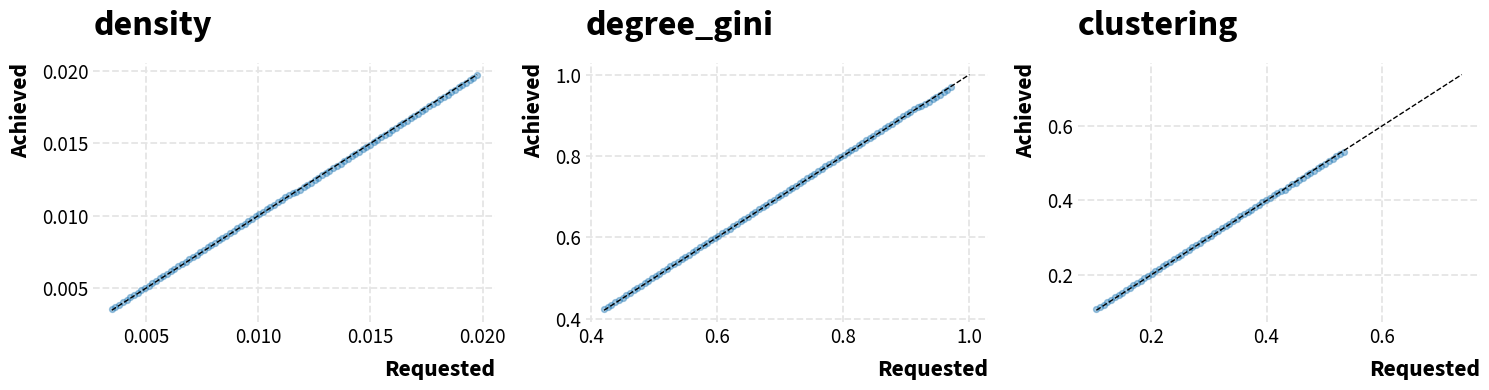

Saved: /Users/Noich001/Desktop/network_inequality_current/e_network_inequality/Figures/sa_variation_plots/ego_network_final_pairplot.png, /Users/Noich001/Desktop/network_inequality_current/e_network_inequality/Figures/sa_variation_plots/ego_network_final_pairplot.pdf


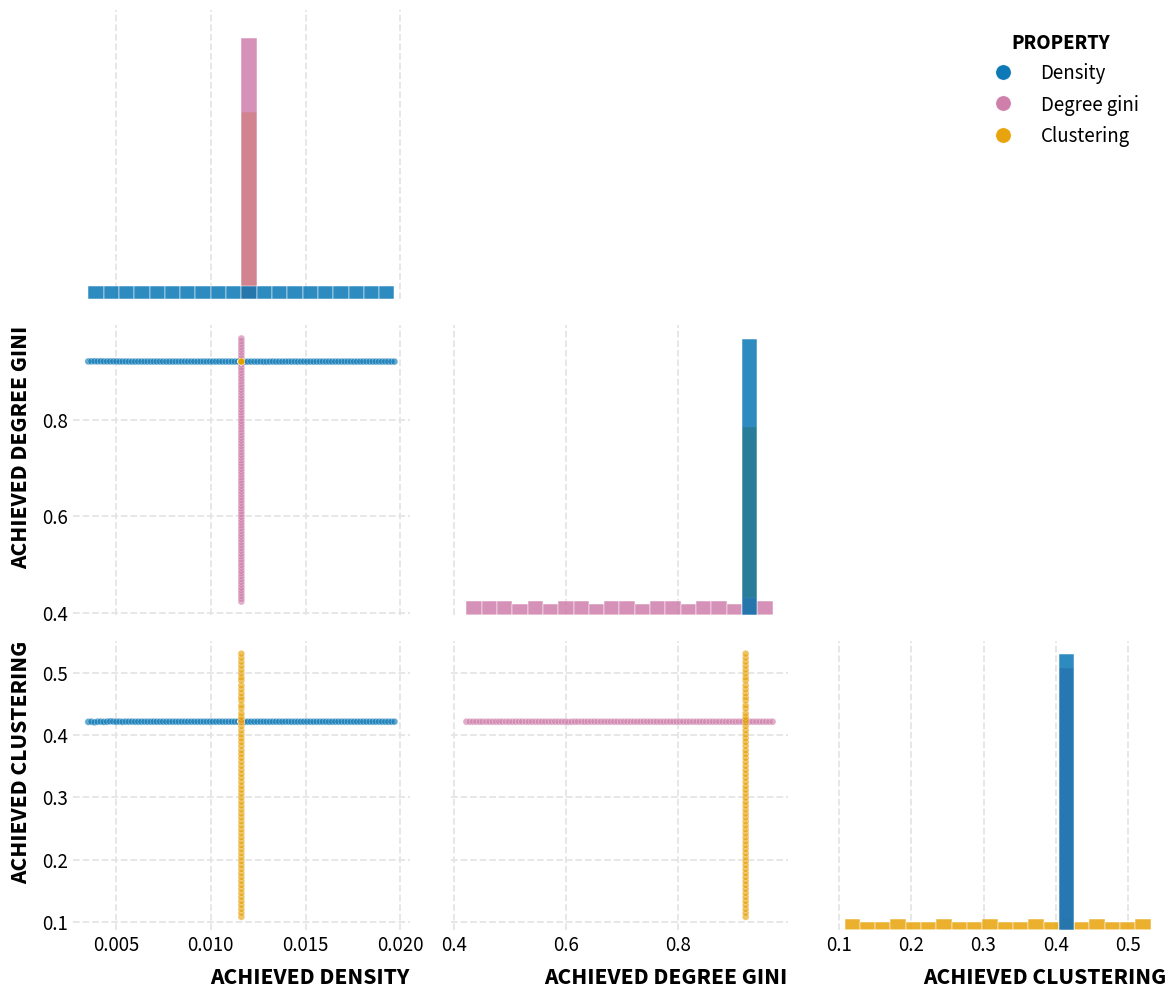

Saved: /Users/Noich001/Desktop/network_inequality_current/e_network_inequality/Figures/sa_variation_plots/ego_network_target_delta_vs_edit_distance.png, /Users/Noich001/Desktop/network_inequality_current/e_network_inequality/Figures/sa_variation_plots/ego_network_target_delta_vs_edit_distance.pdf


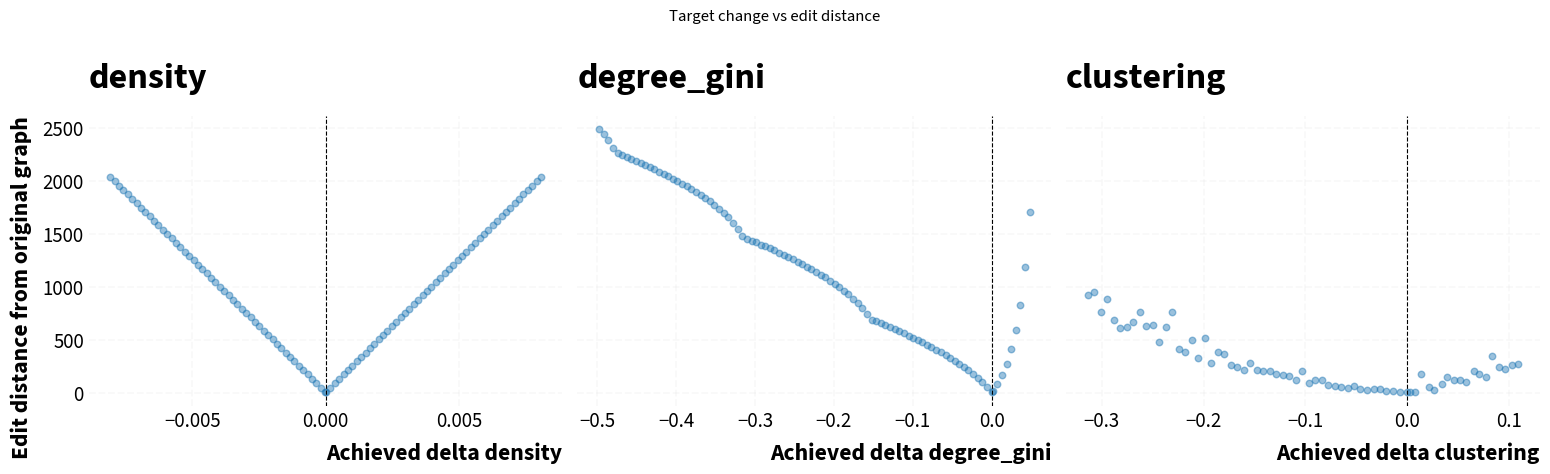


Plots for pud_network
Saved: /Users/Noich001/Desktop/network_inequality_current/e_network_inequality/Figures/sa_variation_plots/pud_network_requested_vs_achieved.png, /Users/Noich001/Desktop/network_inequality_current/e_network_inequality/Figures/sa_variation_plots/pud_network_requested_vs_achieved.pdf


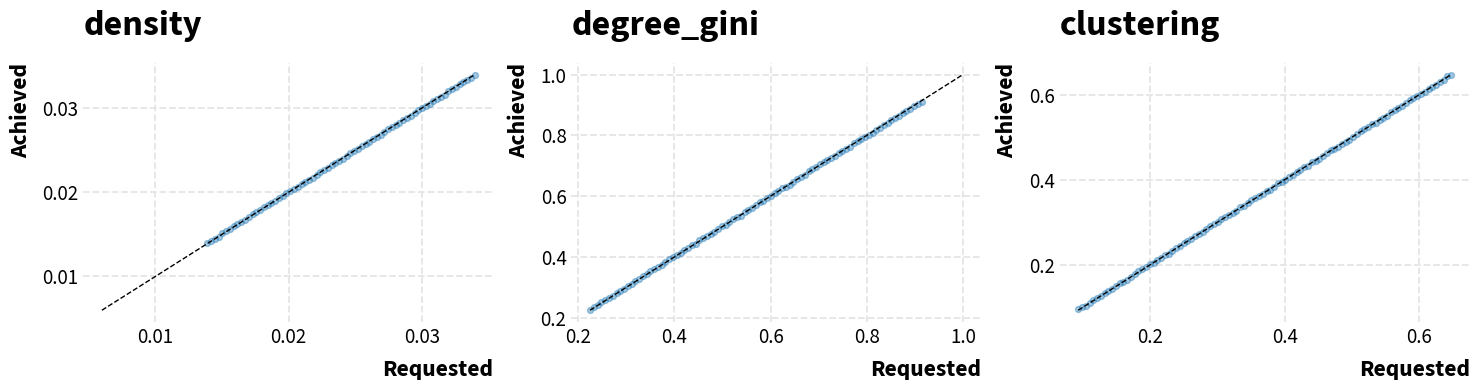

Saved: /Users/Noich001/Desktop/network_inequality_current/e_network_inequality/Figures/sa_variation_plots/pud_network_final_pairplot.png, /Users/Noich001/Desktop/network_inequality_current/e_network_inequality/Figures/sa_variation_plots/pud_network_final_pairplot.pdf


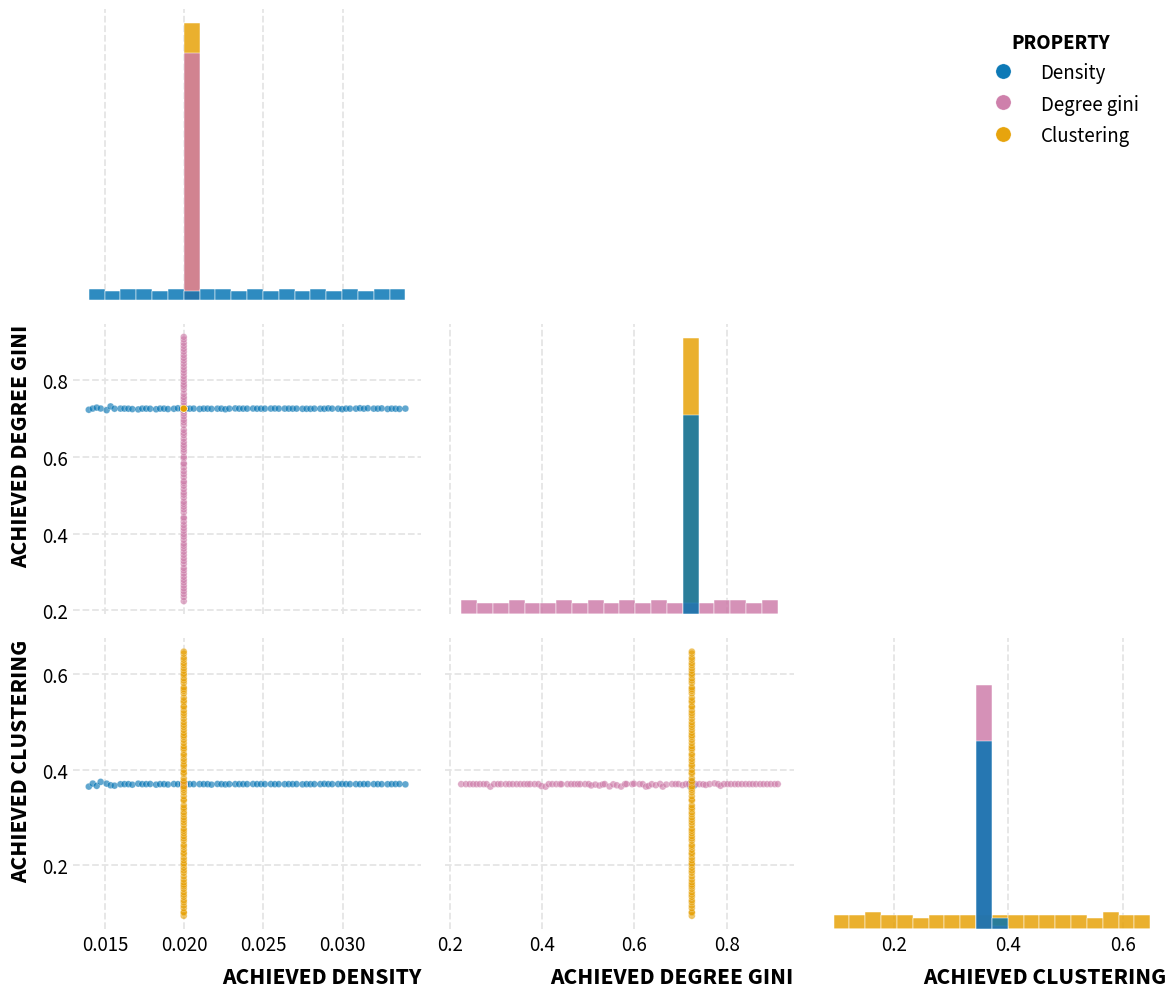

Saved: /Users/Noich001/Desktop/network_inequality_current/e_network_inequality/Figures/sa_variation_plots/pud_network_target_delta_vs_edit_distance.png, /Users/Noich001/Desktop/network_inequality_current/e_network_inequality/Figures/sa_variation_plots/pud_network_target_delta_vs_edit_distance.pdf


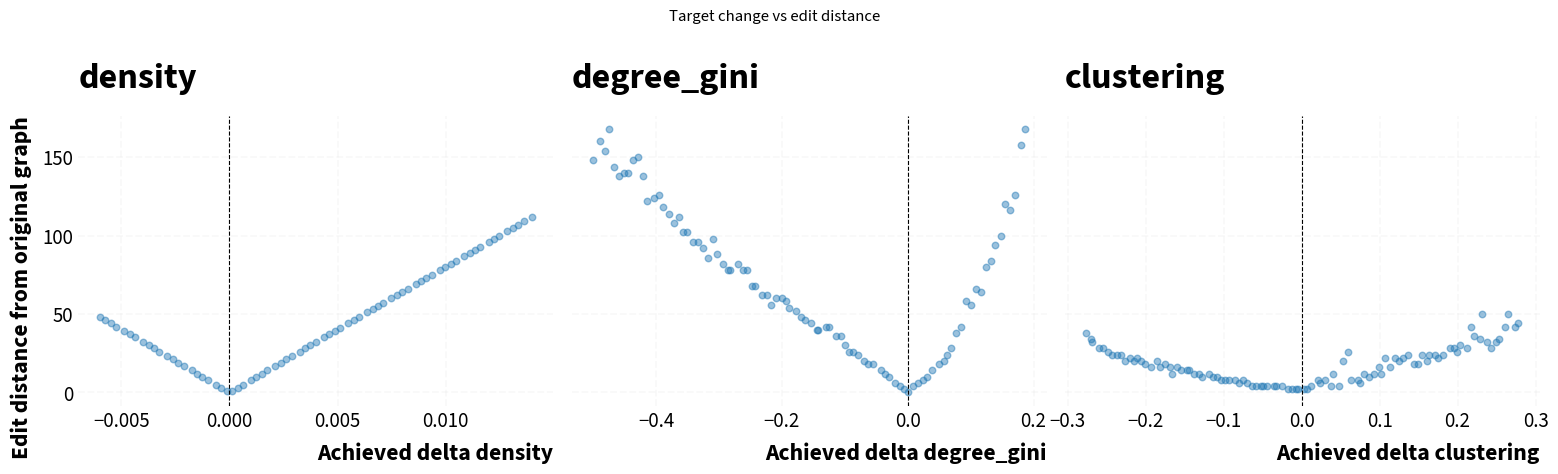


Plots for tobacco_network
Saved: /Users/Noich001/Desktop/network_inequality_current/e_network_inequality/Figures/sa_variation_plots/tobacco_network_requested_vs_achieved.png, /Users/Noich001/Desktop/network_inequality_current/e_network_inequality/Figures/sa_variation_plots/tobacco_network_requested_vs_achieved.pdf


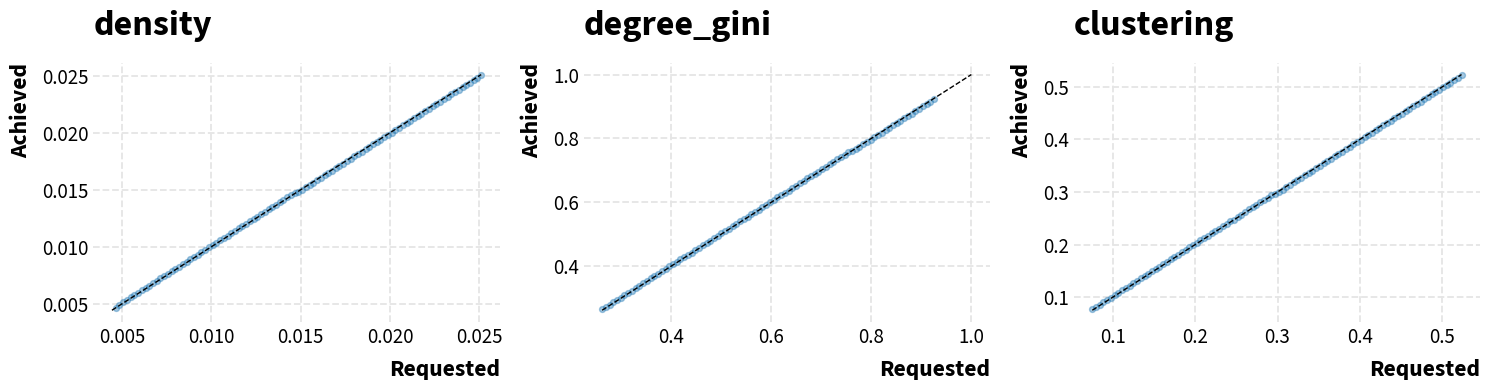

Saved: /Users/Noich001/Desktop/network_inequality_current/e_network_inequality/Figures/sa_variation_plots/tobacco_network_final_pairplot.png, /Users/Noich001/Desktop/network_inequality_current/e_network_inequality/Figures/sa_variation_plots/tobacco_network_final_pairplot.pdf


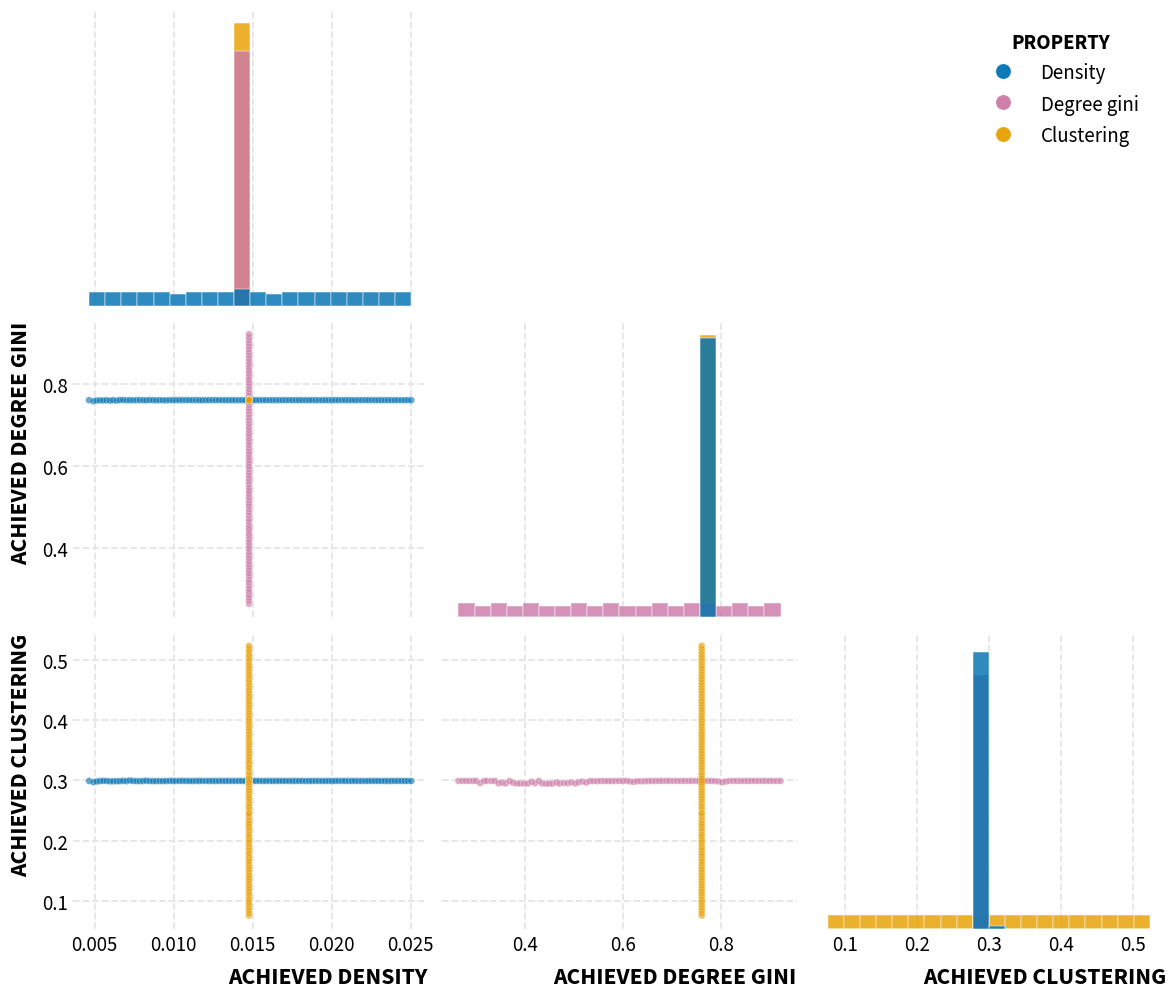

Saved: /Users/Noich001/Desktop/network_inequality_current/e_network_inequality/Figures/sa_variation_plots/tobacco_network_target_delta_vs_edit_distance.png, /Users/Noich001/Desktop/network_inequality_current/e_network_inequality/Figures/sa_variation_plots/tobacco_network_target_delta_vs_edit_distance.pdf


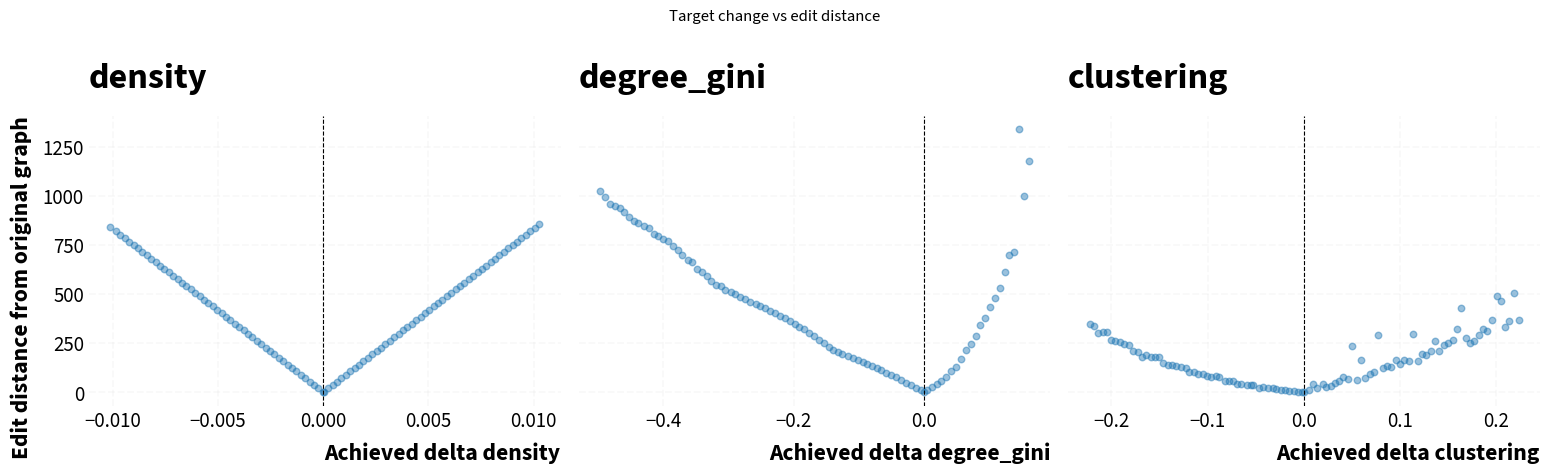

In [30]:
PLOT_OUTPUT_SUBDIR = "sa_variation_plots"

if not combined_results_df.empty:
    for source_id, results_df in combined_results_df.groupby("source_id", sort=True):
        print()
        print(f"Plots for {source_id}")

        fig = plot_requested_vs_achieved(results_df)
        saved_paths = save_plot(fig, _safe_filename(source_id, "requested_vs_achieved"), subdir=PLOT_OUTPUT_SUBDIR)
        print("Saved:", ", ".join(str(path) for path in saved_paths))
        display(fig)
        plt.close(fig)

        grid = plot_final_pairplot(results_df)
        saved_paths = save_plot(grid, _safe_filename(source_id, "final_pairplot"), subdir=PLOT_OUTPUT_SUBDIR)
        print("Saved:", ", ".join(str(path) for path in saved_paths))
        display(grid.fig)
        plt.close(grid.fig)

        fig = plot_target_delta_vs_edit_distance(results_df, facet_by_target=True)
        saved_paths = save_plot(fig, _safe_filename(source_id, "target_delta_vs_edit_distance"), subdir=PLOT_OUTPUT_SUBDIR)
        print("Saved:", ", ".join(str(path) for path in saved_paths))
        display(fig)
        plt.close(fig)

In [31]:
# Replay a few real batch rows with trace recording enabled.
# This reruns the selected SA trajectories with the same source/target/seed,
# but only prepares trace_runs for the final plotting cell.
TRACE_N_RANDOM_RUNS = 10
TRACE_RANDOM_SEED = 23
TRACE_FEASIBLE_ONLY = True

trace_runs: list[dict[str, object]] = []
trace_replay_rows: list[dict[str, object]] = []

if "prepared_sources" not in globals() or not prepared_sources:
    if "_rebuild_prepared_sources_from_saved_run" in globals():
        prepared_sources = _rebuild_prepared_sources_from_saved_run()
    else:
        prepared_sources = {}

if not prepared_sources:
    print("Run the reload cell immediately above the plot section first; trace replay needs baseline GraphState objects.")
elif combined_results_df.empty:
    print("No batch results available for trace replay.")
else:
    trace_candidates = combined_results_df.loc[
        combined_results_df["source_id"].isin(prepared_sources.keys())
    ].copy()
    if TRACE_FEASIBLE_ONLY and "feasible" in trace_candidates.columns:
        trace_candidates = trace_candidates.loc[trace_candidates["feasible"].fillna(False)].copy()

    if trace_candidates.empty:
        print("No candidate rows available for trace replay.")
    else:
        selected_trace_rows_df = trace_candidates.sample(
            n=min(TRACE_N_RANDOM_RUNS, len(trace_candidates)),
            random_state=TRACE_RANDOM_SEED,
        ).copy()
        selected_columns = [
            "source_id",
            "target_stat",
            "target_value_requested",
            "seed",
            "target_value_achieved",
            "edit_distance",
            "target_error",
            "preserve_center",
            "attain_stop_reason",
            "compress_stop_reason",
            "compress_edit_cap_applied",
        ]
        selected_columns = [col for col in selected_columns if col in selected_trace_rows_df.columns]
        display(selected_trace_rows_df[selected_columns])

        trace_source_states = {
            source_id: {
                "state": info["state"],
                "baseline_stats": info["baseline_stats"],
            }
            for source_id, info in prepared_sources.items()
        }

        for run_index, (_, row) in enumerate(selected_trace_rows_df.iterrows()):
            source_id = str(row["source_id"])
            cfg = prepared_sources[source_id]["cfg"]
            run = replay_result_trace(
                row,
                {source_id: trace_source_states[source_id]},
                cfg,
                run_index=run_index,
                record_state_matrices=False,
            )
            trace_runs.append(run)
            trace_replay_rows.append(run["row"])

        trace_replay_summary_df = pd.DataFrame(trace_replay_rows)
        display(trace_replay_summary_df)
        print("trace_runs ready; rerun the final cell to adjust trace plots without replaying SA.")

,source_id,target_stat,target_value_requested,seed,target_value_achieved,edit_distance,target_error,preserve_center,attain_stop_reason,compress_stop_reason,compress_edit_cap_applied
141,ego_network,degree_gini,0.660454,1410007,0.662641,1280.0,0.002187,2.175319e-07,first_feasible,compress_no_improvement_patience,1.0
174,ego_network,degree_gini,0.853644,1740007,0.855985,380.0,0.002341,4.112905e-06,first_feasible,compress_no_improvement_patience,1.0
757,tobacco_network,degree_gini,0.686618,1570007,0.689091,122.0,0.002473,4.346838e-04,first_feasible,compress_no_improvement_patience,1.0
161,ego_network,degree_gini,0.777539,1610007,0.779822,654.0,0.002283,5.087502e-09,first_feasible,compress_no_improvement_patience,1.0
584,pud_network,clustering,0.563795,2840007,0.565517,28.0,0.001723,0.000000e+00,first_feasible,compress_no_improvement_patience,0.0
623,tobacco_network,density,0.009232,230007,0.009311,454.0,0.000079,1.439976e-02,first_feasible,compress_no_improvement_patience,1.0
147,ego_network,degree_gini,0.695580,1470007,0.697909,1140.0,0.002329,1.995685e-04,first_feasible,compress_no_improvement_patience,1.0
258,ego_network,clustering,0.476006,2580007,0.473780,114.0,0.002226,0.000000e+00,first_feasible,compress_no_improvement_patience,0.0
206,ego_network,clustering,0.143760,2060007,0.146270,620.0,0.002510,0.000000e+00,first_feasible,compress_no_improvement_patience,0.0
112,ego_network,degree_gini,0.490681,1120007,0.492951,2110.0,0.002270,8.242867e-08,first_feasible,compress_no_improvement_patience,1.0


,inspection_run_index,result_index,source_id,target_stat,target_value_requested,seed,batch_feasible,replay_feasible,batch_edit_distance,replay_edit_distance,...,attain_stop_reason,attain_first_feasible_step,attain_best_feasible_edit_distance,compress_stop_reason,compress_best_feasible_edit_distance,compress_start_edit_distance,compress_uncapped_best_feasible_edit_distance,compress_edit_cap_applied,attain_acceptance_rate,compress_acceptance_rate
0,0,141,ego_network,degree_gini,0.660454,1410007,True,True,1280.0,1280,...,first_feasible,640,1280,compress_no_improvement_patience,1280,1280,1286,1,1.0,0.997788
1,1,174,ego_network,degree_gini,0.853644,1740007,True,True,380.0,380,...,first_feasible,190,380,compress_no_improvement_patience,380,380,392,1,1.0,0.995511
2,2,757,tobacco_network,degree_gini,0.686618,1570007,True,True,122.0,122,...,first_feasible,61,122,compress_no_improvement_patience,122,122,132,1,1.0,0.995356
3,3,161,ego_network,degree_gini,0.777539,1610007,True,True,654.0,654,...,first_feasible,327,654,compress_no_improvement_patience,654,654,672,1,1.0,1.000000
4,4,584,pud_network,clustering,0.563795,2840007,True,True,28.0,24,...,first_feasible,49,90,compress_no_improvement_patience,24,90,24,0,1.0,0.825342
5,5,623,tobacco_network,density,0.009232,230007,True,True,454.0,454,...,first_feasible,454,454,compress_no_improvement_patience,454,454,460,1,1.0,0.988909
6,6,147,ego_network,degree_gini,0.695580,1470007,True,True,1140.0,1140,...,first_feasible,570,1140,compress_no_improvement_patience,1140,1140,1140,0,1.0,0.997691
7,7,258,ego_network,clustering,0.476006,2580007,True,True,114.0,180,...,first_feasible,340,976,compress_no_improvement_patience,180,976,180,0,1.0,0.906769
8,8,206,ego_network,clustering,0.143760,2060007,True,True,620.0,620,...,first_feasible,275,1088,compress_no_improvement_patience,620,1088,620,0,1.0,0.937452
9,9,112,ego_network,degree_gini,0.490681,1120007,True,True,2110.0,2108,...,first_feasible,1054,2108,compress_no_improvement_patience,2108,2108,2114,1,1.0,1.000000


trace_runs ready; rerun the final cell to adjust trace plots without replaying SA.


Saved: /Users/Noich001/Desktop/network_inequality_current/e_network_inequality/Figures/sa_variation_plots/trace_replays/ego_network_trace_replay_row_141_degree_gini_seed_1410007.png, /Users/Noich001/Desktop/network_inequality_current/e_network_inequality/Figures/sa_variation_plots/trace_replays/ego_network_trace_replay_row_141_degree_gini_seed_1410007.pdf


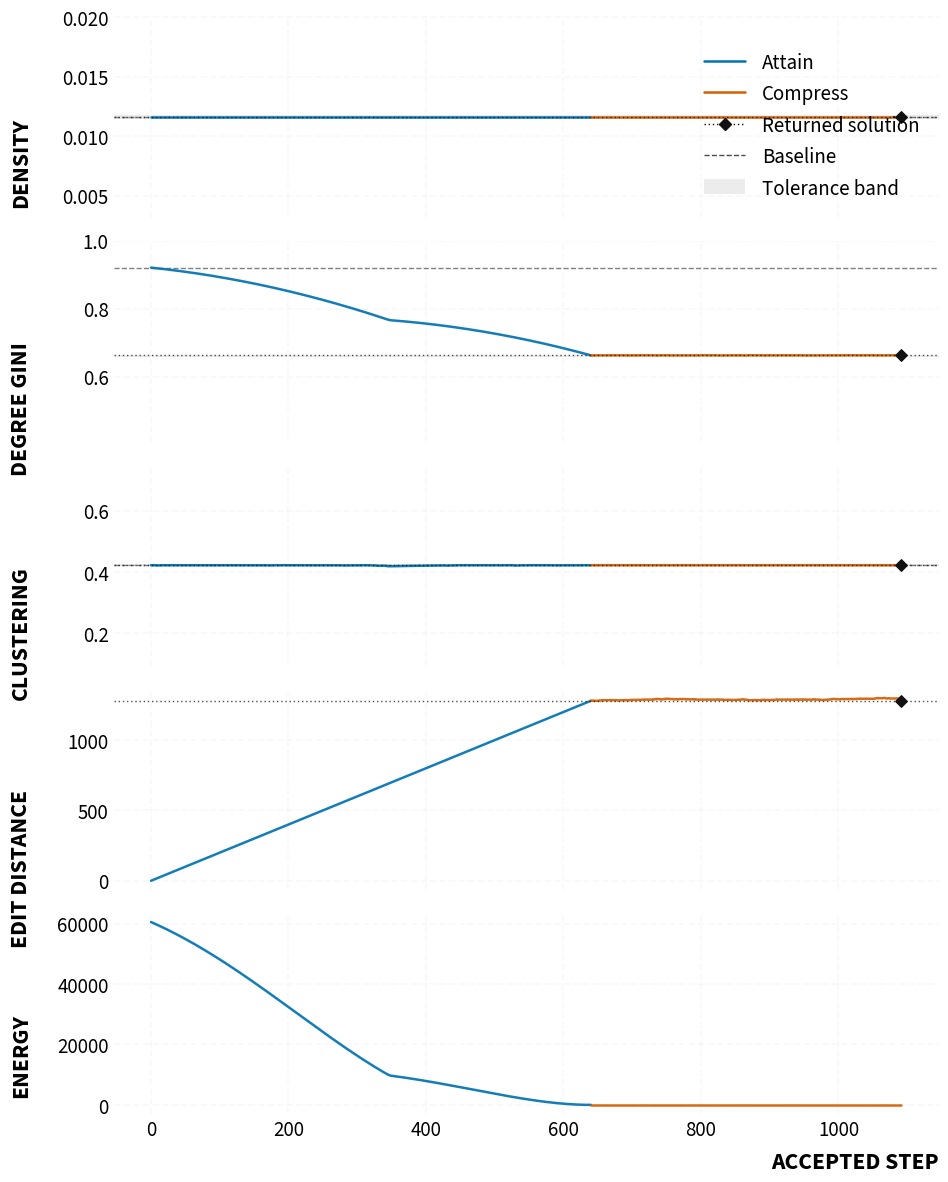

Saved: /Users/Noich001/Desktop/network_inequality_current/e_network_inequality/Figures/sa_variation_plots/trace_replays/ego_network_trace_replay_row_174_degree_gini_seed_1740007.png, /Users/Noich001/Desktop/network_inequality_current/e_network_inequality/Figures/sa_variation_plots/trace_replays/ego_network_trace_replay_row_174_degree_gini_seed_1740007.pdf


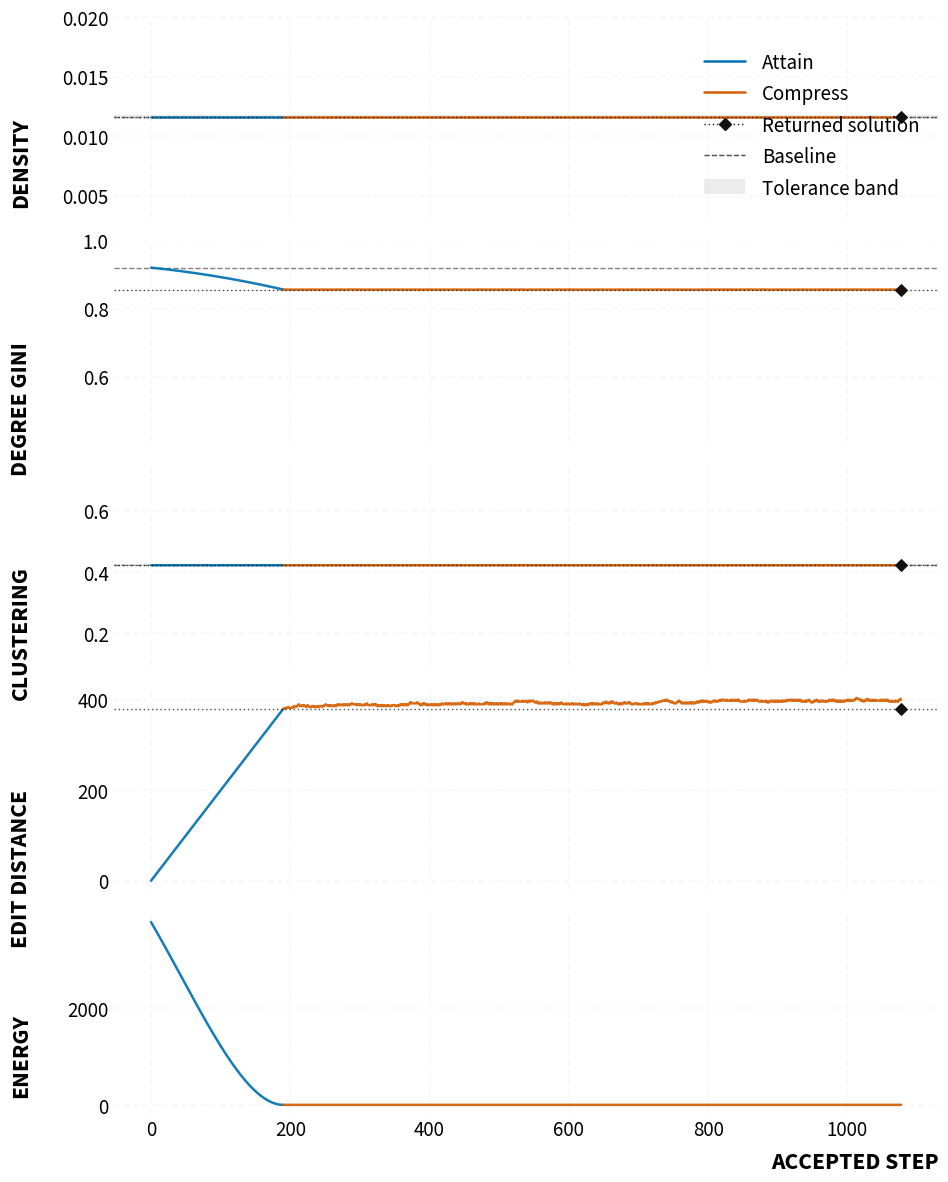

Saved: /Users/Noich001/Desktop/network_inequality_current/e_network_inequality/Figures/sa_variation_plots/trace_replays/ego_network_trace_replay_row_161_degree_gini_seed_1610007.png, /Users/Noich001/Desktop/network_inequality_current/e_network_inequality/Figures/sa_variation_plots/trace_replays/ego_network_trace_replay_row_161_degree_gini_seed_1610007.pdf


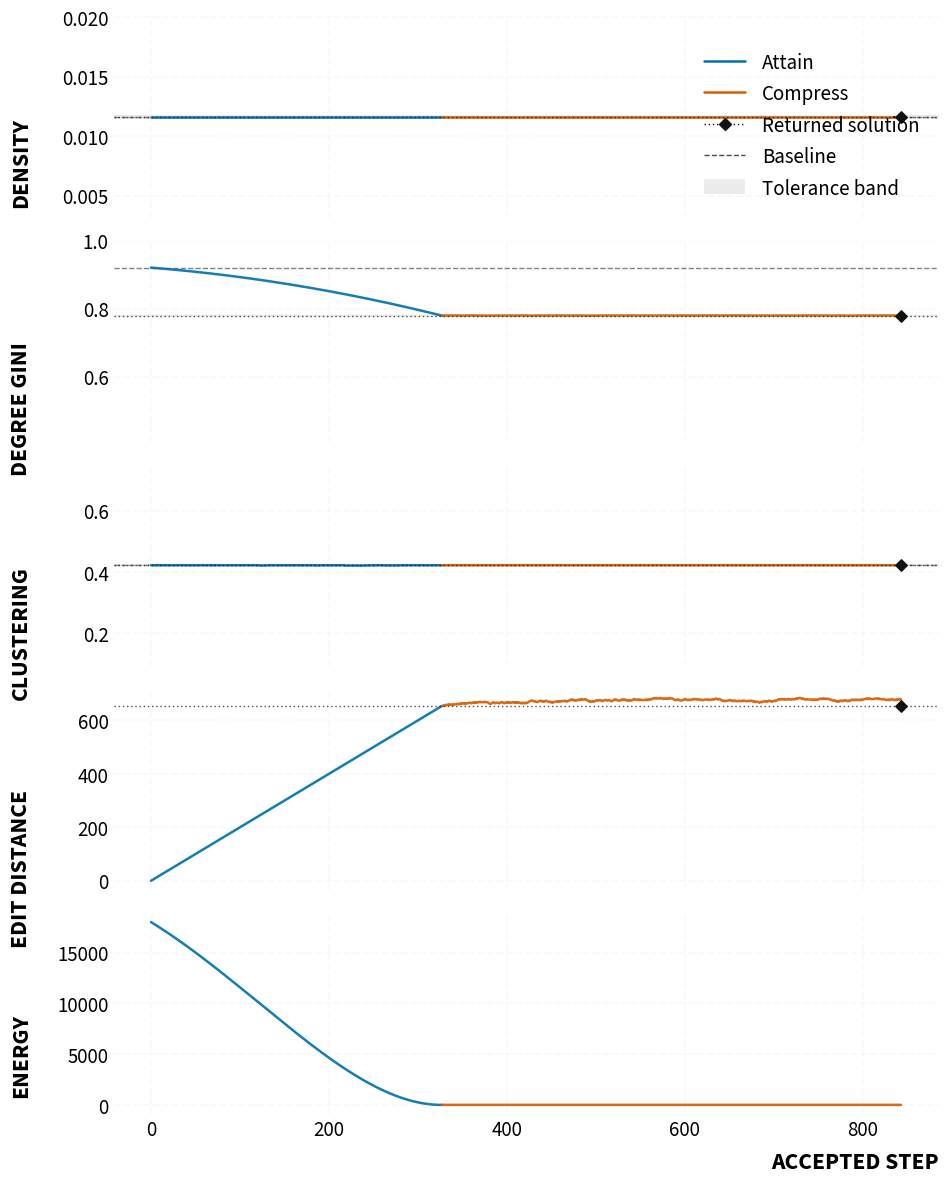

Saved: /Users/Noich001/Desktop/network_inequality_current/e_network_inequality/Figures/sa_variation_plots/trace_replays/ego_network_trace_replay_row_147_degree_gini_seed_1470007.png, /Users/Noich001/Desktop/network_inequality_current/e_network_inequality/Figures/sa_variation_plots/trace_replays/ego_network_trace_replay_row_147_degree_gini_seed_1470007.pdf


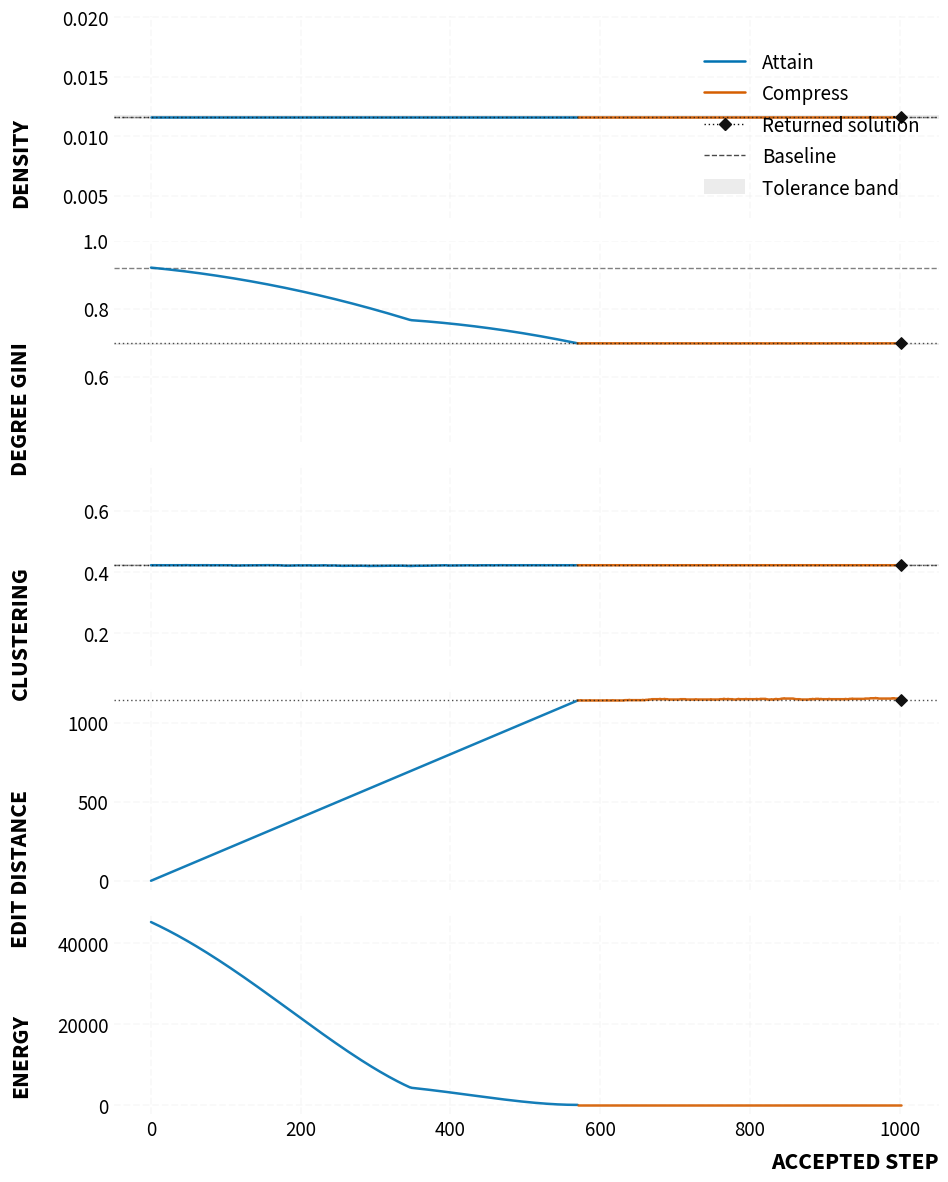

Saved: /Users/Noich001/Desktop/network_inequality_current/e_network_inequality/Figures/sa_variation_plots/trace_replays/ego_network_trace_replay_row_258_clustering_seed_2580007.png, /Users/Noich001/Desktop/network_inequality_current/e_network_inequality/Figures/sa_variation_plots/trace_replays/ego_network_trace_replay_row_258_clustering_seed_2580007.pdf


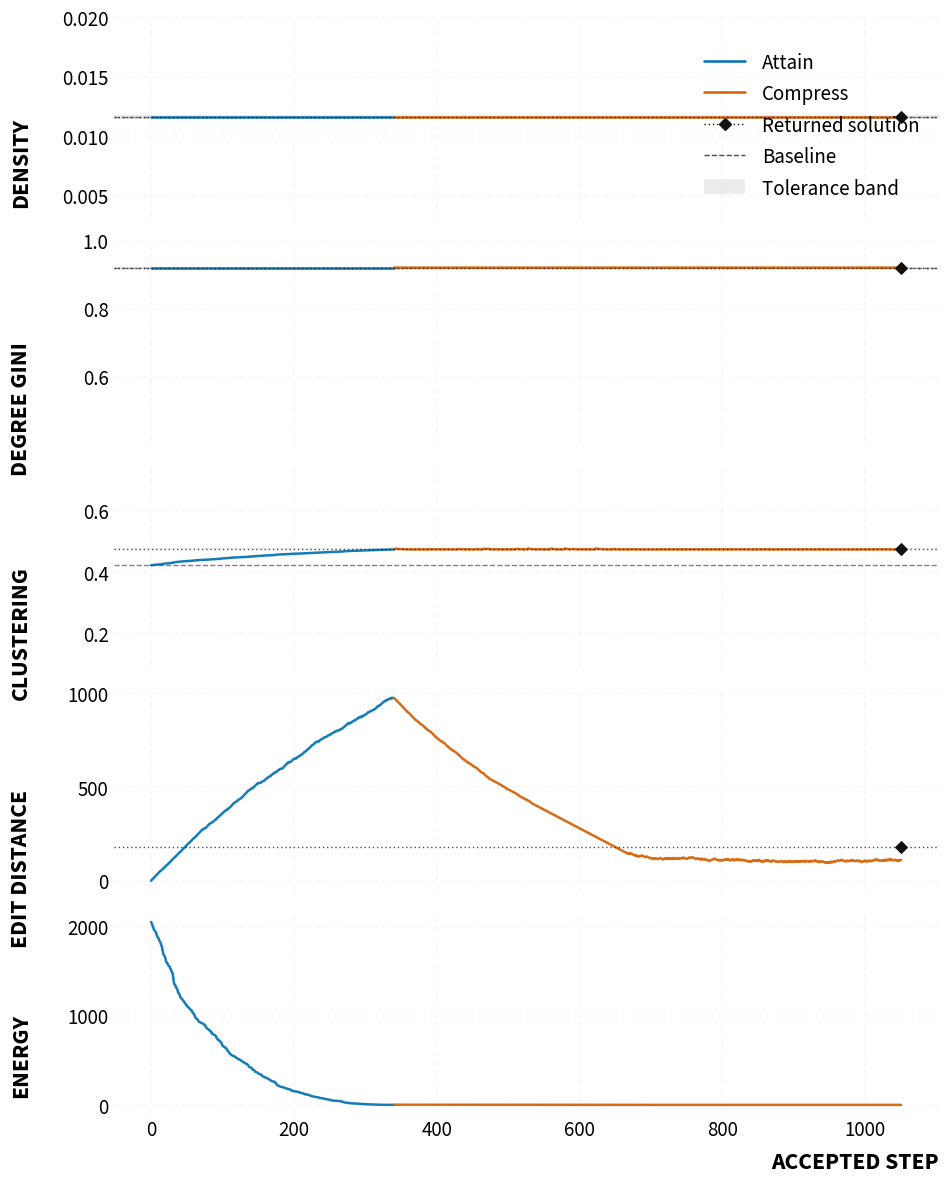

Saved: /Users/Noich001/Desktop/network_inequality_current/e_network_inequality/Figures/sa_variation_plots/trace_replays/ego_network_trace_replay_row_206_clustering_seed_2060007.png, /Users/Noich001/Desktop/network_inequality_current/e_network_inequality/Figures/sa_variation_plots/trace_replays/ego_network_trace_replay_row_206_clustering_seed_2060007.pdf


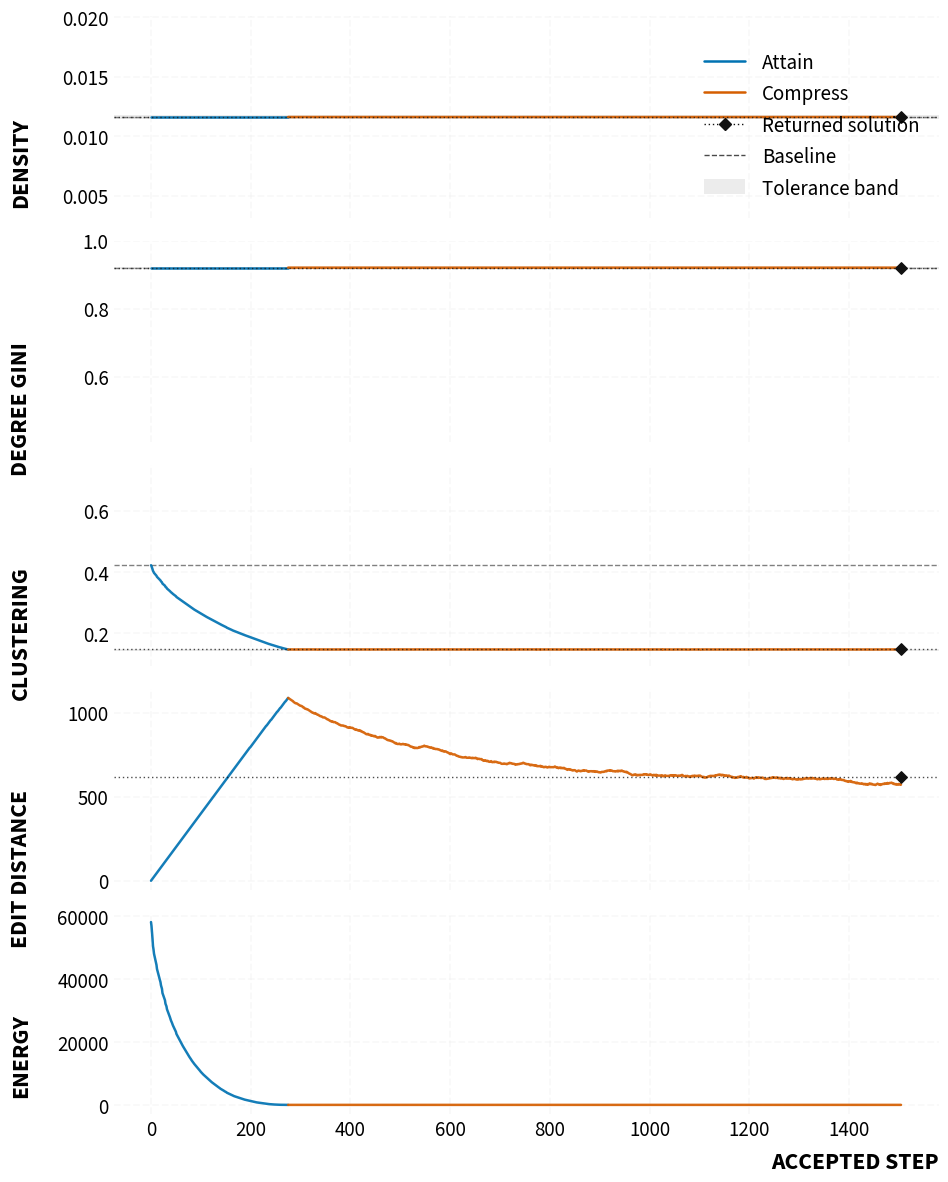

Saved: /Users/Noich001/Desktop/network_inequality_current/e_network_inequality/Figures/sa_variation_plots/trace_replays/ego_network_trace_replay_row_112_degree_gini_seed_1120007.png, /Users/Noich001/Desktop/network_inequality_current/e_network_inequality/Figures/sa_variation_plots/trace_replays/ego_network_trace_replay_row_112_degree_gini_seed_1120007.pdf


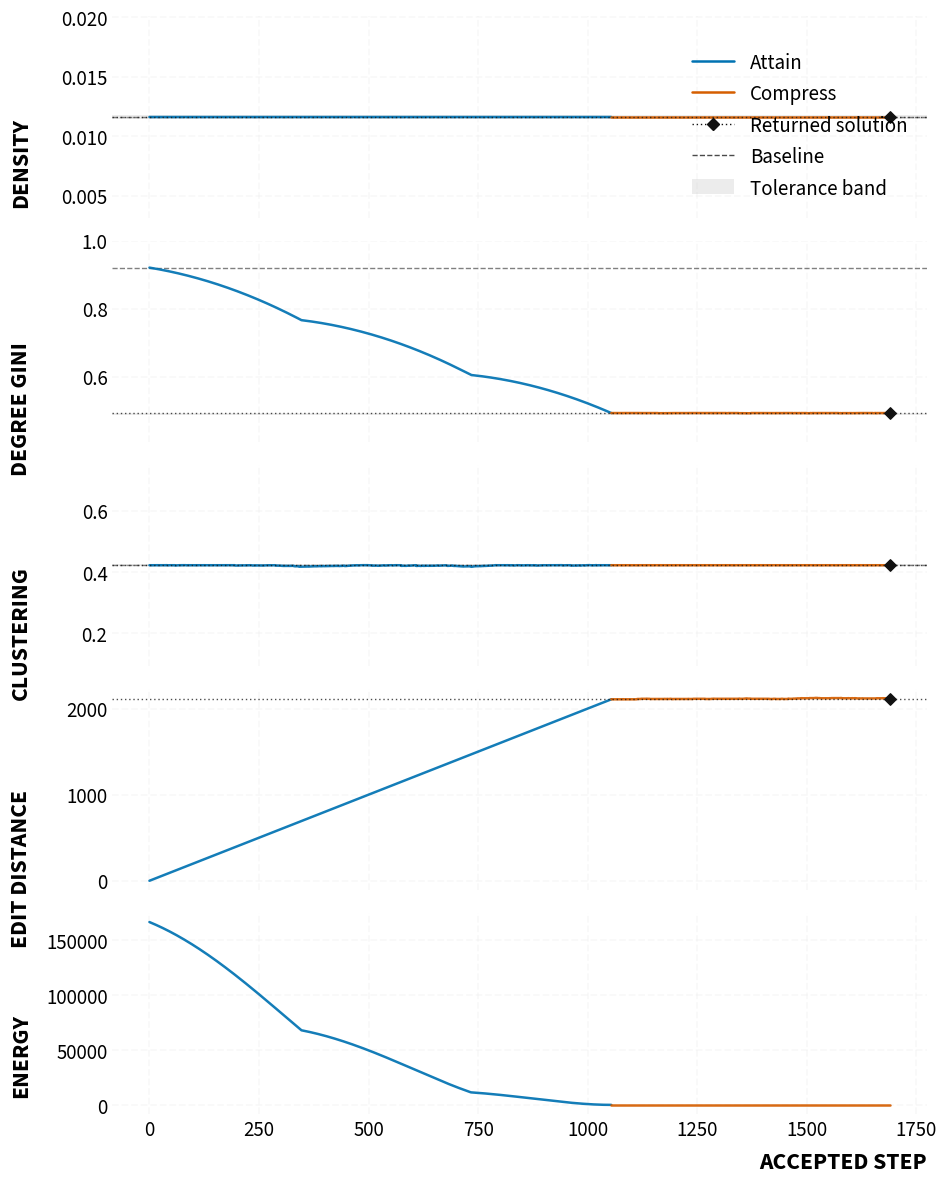

Saved: /Users/Noich001/Desktop/network_inequality_current/e_network_inequality/Figures/sa_variation_plots/trace_replays/pud_network_trace_replay_row_584_clustering_seed_2840007.png, /Users/Noich001/Desktop/network_inequality_current/e_network_inequality/Figures/sa_variation_plots/trace_replays/pud_network_trace_replay_row_584_clustering_seed_2840007.pdf


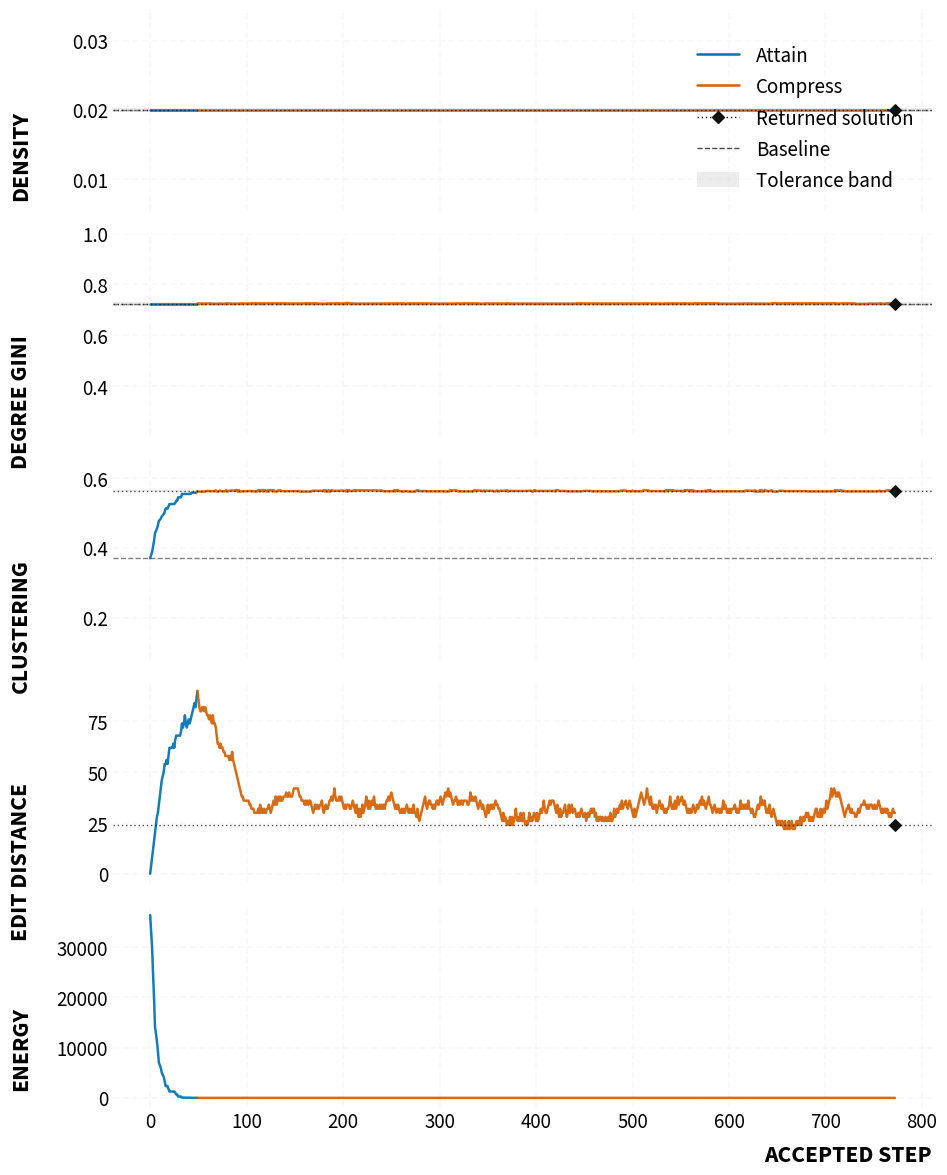

Saved: /Users/Noich001/Desktop/network_inequality_current/e_network_inequality/Figures/sa_variation_plots/trace_replays/tobacco_network_trace_replay_row_757_degree_gini_seed_1570007.png, /Users/Noich001/Desktop/network_inequality_current/e_network_inequality/Figures/sa_variation_plots/trace_replays/tobacco_network_trace_replay_row_757_degree_gini_seed_1570007.pdf


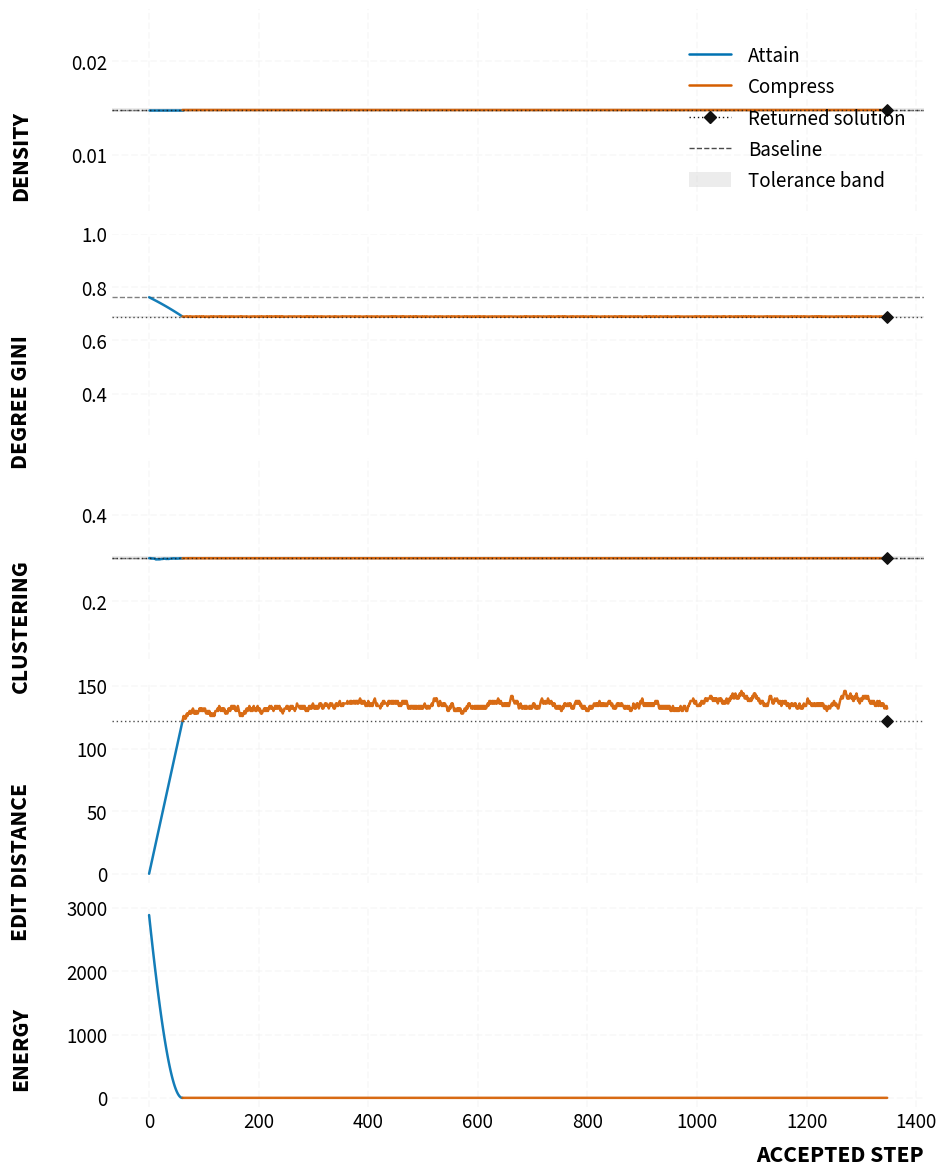

Saved: /Users/Noich001/Desktop/network_inequality_current/e_network_inequality/Figures/sa_variation_plots/trace_replays/tobacco_network_trace_replay_row_623_density_seed_230007.png, /Users/Noich001/Desktop/network_inequality_current/e_network_inequality/Figures/sa_variation_plots/trace_replays/tobacco_network_trace_replay_row_623_density_seed_230007.pdf


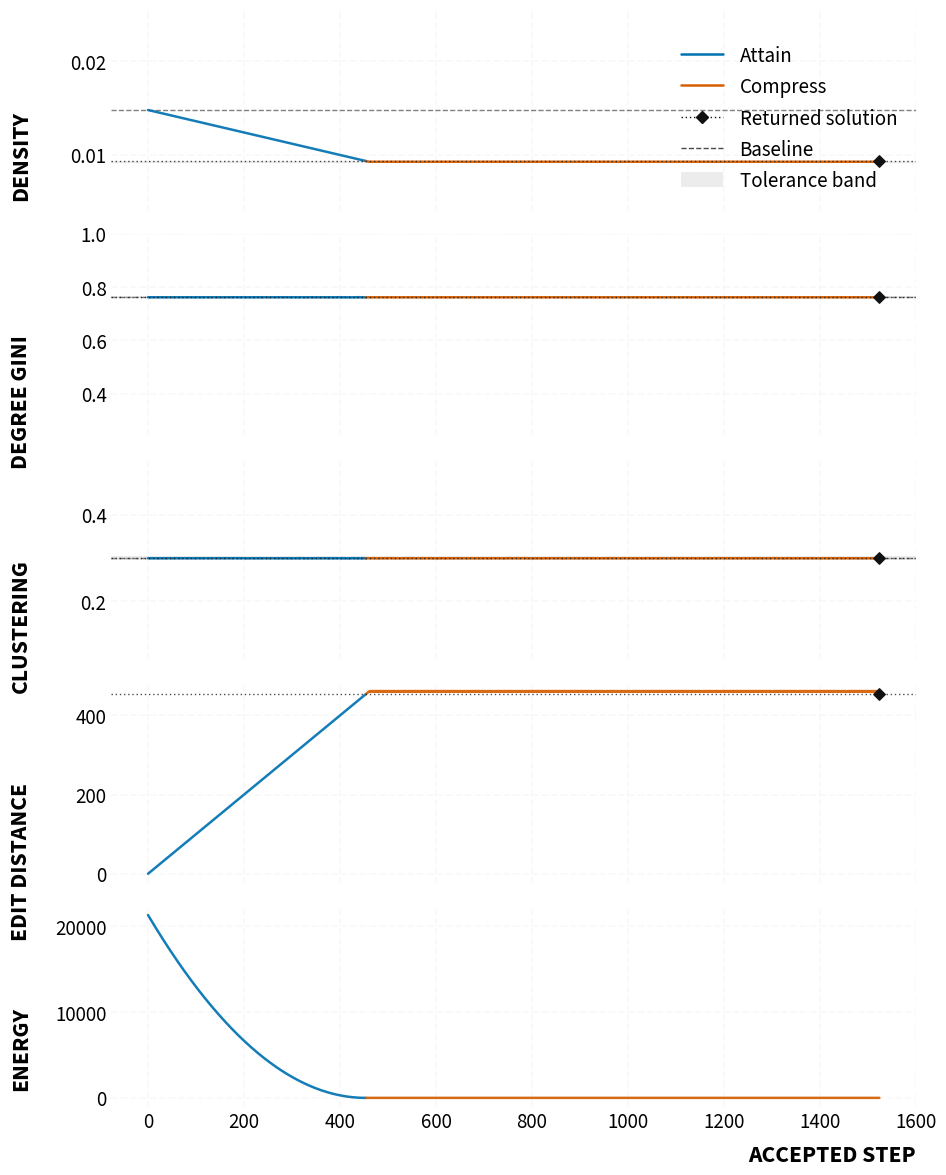

In [32]:
# Plot already prepared trace runs. Rerun this cell after editing plot helpers.
TRACE_PLOT_OUTPUT_SUBDIR = "sa_variation_plots/trace_replays"

if "trace_runs" not in globals() or not trace_runs:
    print("No trace_runs available. Run the trace replay preparation cell first.")
elif "combined_target_grids_df" not in globals() or combined_target_grids_df.empty:
    print("No target-grid table available. Run the reload cell above the plot section first.")
elif "prepared_sources" not in globals() or not prepared_sources:
    print("No prepared source configs available. Run the reload cell above the plot section first.")
else:
    trace_figures: list[tuple[dict[str, object], plt.Figure]] = []
    for source_id in sorted({str(run["source_id"]) for run in trace_runs}):
        source_runs = [run for run in trace_runs if str(run["source_id"]) == source_id]
        if source_id not in prepared_sources:
            print(f"Skipping {source_id}: no prepared source config available.")
            continue
        source_grid_df = combined_target_grids_df
        if "source_id" in source_grid_df.columns:
            source_grid_df = source_grid_df.loc[source_grid_df["source_id"] == source_id]
        source_figures = plot_replayed_result_traces(
            source_runs,
            source_grid_df,
            prepared_sources[source_id]["cfg"],
        )
        trace_figures.extend(zip(source_runs, source_figures))

    if not trace_figures:
        print("No trace figures were created.")
    else:
        for run, fig in trace_figures:
            saved_paths = save_plot(
                fig,
                _safe_filename(
                    run.get("source_id"),
                    "trace_replay",
                    f"row_{run.get('result_index')}",
                    run.get("target_stat"),
                    f"seed_{run.get('seed')}",
                ),
                subdir=TRACE_PLOT_OUTPUT_SUBDIR,
            )
            print("Saved:", ", ".join(str(path) for path in saved_paths))
            display(fig)
            plt.close(fig)